# Phyloseq analysis
- combo from Nikea https://github.com/nikeaulrich/DR_SCTLD/blob/main/DR_phyloseq.ipynb and my old https://github.com/brookewicz/CBC_metagenomics/blob/main/pstr/pstr_taxonomy_plots.ipynb

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [138]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [139]:
# see installation from 4Taxa_Trials in PSTR

In [140]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)

## Upload Data

In [141]:
setwd("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken")

### OTU Table

In [142]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,S
2,2819098,Vibrio sp. SCSIO 43153,S
3,2819101,Vibrio sp. SCSIO 43136,S
4,2912314,Vibrio sp. JC009,S
5,2751178,Vibrio sp. B1FLJ16,S
6,2751176,Vibrio sp. B1ASS3,S


In [143]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [144]:
head(taxa)

,otuid,species
,<int>,<chr>
1,3021011,Vibrio sp. SCSIO 43137
2,2819098,Vibrio sp. SCSIO 43153
3,2819101,Vibrio sp. SCSIO 43136
4,2912314,Vibrio sp. JC009
5,2751178,Vibrio sp. B1FLJ16
6,2751176,Vibrio sp. B1ASS3


In [145]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
3021011,Vibrio sp. SCSIO 43137
2819098,Vibrio sp. SCSIO 43153
2819101,Vibrio sp. SCSIO 43136
2912314,Vibrio sp. JC009
2751178,Vibrio sp. B1FLJ16
2751176,Vibrio sp. B1ASS3


In [146]:
str(taxa)

'data.frame':	15891 obs. of  1 variable:
 $ species: chr  "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" "Vibrio sp. SCSIO 43136" "Vibrio sp. JC009" ...


In [147]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:15891, 1] "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:15891] "3021011" "2819098" "2819101" "2912314" ...
  ..$ : chr "species"


In [148]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [149]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


[1] 15892   224

In [150]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [151]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
# column_list <- readLines("DR_column_order.txt")
# otu_table <- otu_table[, column_list]
# head(otu_table)

In [152]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,0.0000,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,1251.3442,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,0.0000,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,166.1942,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [153]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,554927.0000,341857.0000,626517.000,153301.0000,107501.0000,558719.0000,197513.0000,233262.000,130231.00,102290.0000,⋯,212713.0000,1259397.00,274260.000,890665.0000,1120943.000,1.108440e+06,1.636020e+07,4494966.00,1.061326e+07,287599902
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,40185.6022,219368.48,28706.337,7715.5833,269447.242,2.435856e+02,3.674441e+05,308665.07,1.248429e+04,17997644
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,12777.7804,93354.20,2140.305,191.9914,9283.255,1.101548e+03,1.559150e+03,6292.15,6.112587e+05,4938561
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,42564.3943,15603.50,43342.084,57275.1820,17986.642,3.924073e+04,2.506082e+00,0.00,3.109318e+00,3624902
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,404.3006,42190.03,21403.048,8595.8245,62173.545,6.946700e+01,1.412656e+05,111969.70,2.167101e+01,2672541
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,13370.1278,24553.02,5079.122,798.2799,24815.713,8.480387e+01,2.769648e+04,39314.87,4.633826e+03,2465154


In [154]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]

# remove sum col
otus_sorted$Sum <- NULL

head(otus_sorted)
dim (otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


[1] 15891   222

In [155]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


### Metadata

In [156]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [157]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [158]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [159]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [160]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [161]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony<-colony %>%
    filter(colony_id %in% colony_list)

In [162]:
# merge sample and colony data 
sample_colony=merge(metadata, colony, by="colony_id")

In [163]:
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,group,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,T1_12_PSTR,052022_BEL_CBC_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,52022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
2,T1_12_PSTR,102019_BEL_CBC_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,102019_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
3,T1_12_PSTR,122022_BEL_CBC_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,122022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
4,T1_13_PAST,122022_BEL_CBC_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,122022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
5,T1_13_PAST,052022_BEL_CBC_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,52022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
6,T1_13_PAST,062019_BEL_CBC_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,62019_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy


In [164]:
setequal(metadata$colony_id, colony$colony_id)

[1] FALSE

In [165]:
missing_in_metadat <- setdiff(colony$colony_id, metadata$colony_id)

# IDs in df2 that are missing from df1
missing_in_colony <- setdiff(metadata$colony_id, colony$colony_id)
missing_in_metadat # none missing from metadata

character(0)

In [166]:
missing_in_colony 
# only NAs and an accidental sample are missing in colony data (negative controls - no colony ID)

[1] "T2_AS_OANN" NA

In [167]:
# view AS
metadata %>%
    filter(colony_id == 'T2_AS_OANN')
# hmm notes in cbc samples nor accidental sample tracker doesnt tell me what colony its supposed to be
# will have to remove

metadata %>%
    filter(is.na(colony_id))

sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_107_OANN,122022,12/4/22,SR30N,2,AS,ORBI,107,Diseased_Tissue,T2_AS_OANN,122022_OANN_Diseased_Tissue


sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
7_11_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
7_3_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
Negative_extract_11-2-24,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative


In [168]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [169]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [170]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [171]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

In [172]:
table(sample_colony$RS)


  Resistant Susceptible 
        108         109 

In [173]:
test<-102019
# format(test,"%m %Y")
format(my(test), "%Y")

[1] "2019"

In [174]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y"))

In [175]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [176]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019


## PhyloSeq

In [177]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [178]:
TAX=tax_table(taxonomy)

In [179]:
SAMP=sample_data(sample_colony)

In [180]:
# Create phyloseq object
sctld_all<-phyloseq(OTU, SAMP, TAX)
sctld_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 21 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 1 taxonomic ranks ]

In [181]:
# sctld_all.ord <- ordinate(sctld_all, "NMDS", "bray", trymax=1000)

In [182]:
options(repr.plot.width=10, repr.plot.height=10)

In [183]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,05/24/22,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022


In [184]:
# remove outlier for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_all2 <- prune_samples(!(sample_names(sctld_all) %in% outlier), sctld_all)
sctld_all2.ord <- ordinate(sctld_all2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.116542 
Run 1 stress 0.1205375 
Run 2 stress 0.1165537 
... Procrustes: rmse 0.003416447  max resid 0.04914269 
Run 3 stress 0.1169864 
... Procrustes: rmse 0.008726855  max resid 0.1123891 
Run 4 stress 0.1211355 
Run 5 stress 0.1171847 
Run 6 stress 0.1209408 
Run 7 stress 0.1165548 
... Procrustes: rmse 0.003116326  max resid 0.04418715 
Run 8 stress 0.1169865 
... Procrustes: rmse 0.008723036  max resid 0.1123182 
Run 9 stress 0.1165464 
... Procrustes: rmse 0.0003715642  max resid 0.004245789 
... Similar to previous best
Run 10 stress 0.1171908 
Run 11 stress 0.1169864 
... Procrustes: rmse 0.008735607  max resid 0.1124914 
Run 12 stress 0.1209407 
Run 13 stress 0.1165546 
... Procrustes: rmse 0.00309573  max resid 0.04394695 
Run 14 stress 0.1165522 
... Procrustes: rmse 0.003061393  max resid 0.04398114 
Run 15 stress 0.1169867 
... Procrustes: rmse 0.008773465  max resid 0.1130501 
Run 16 stress 0.11698

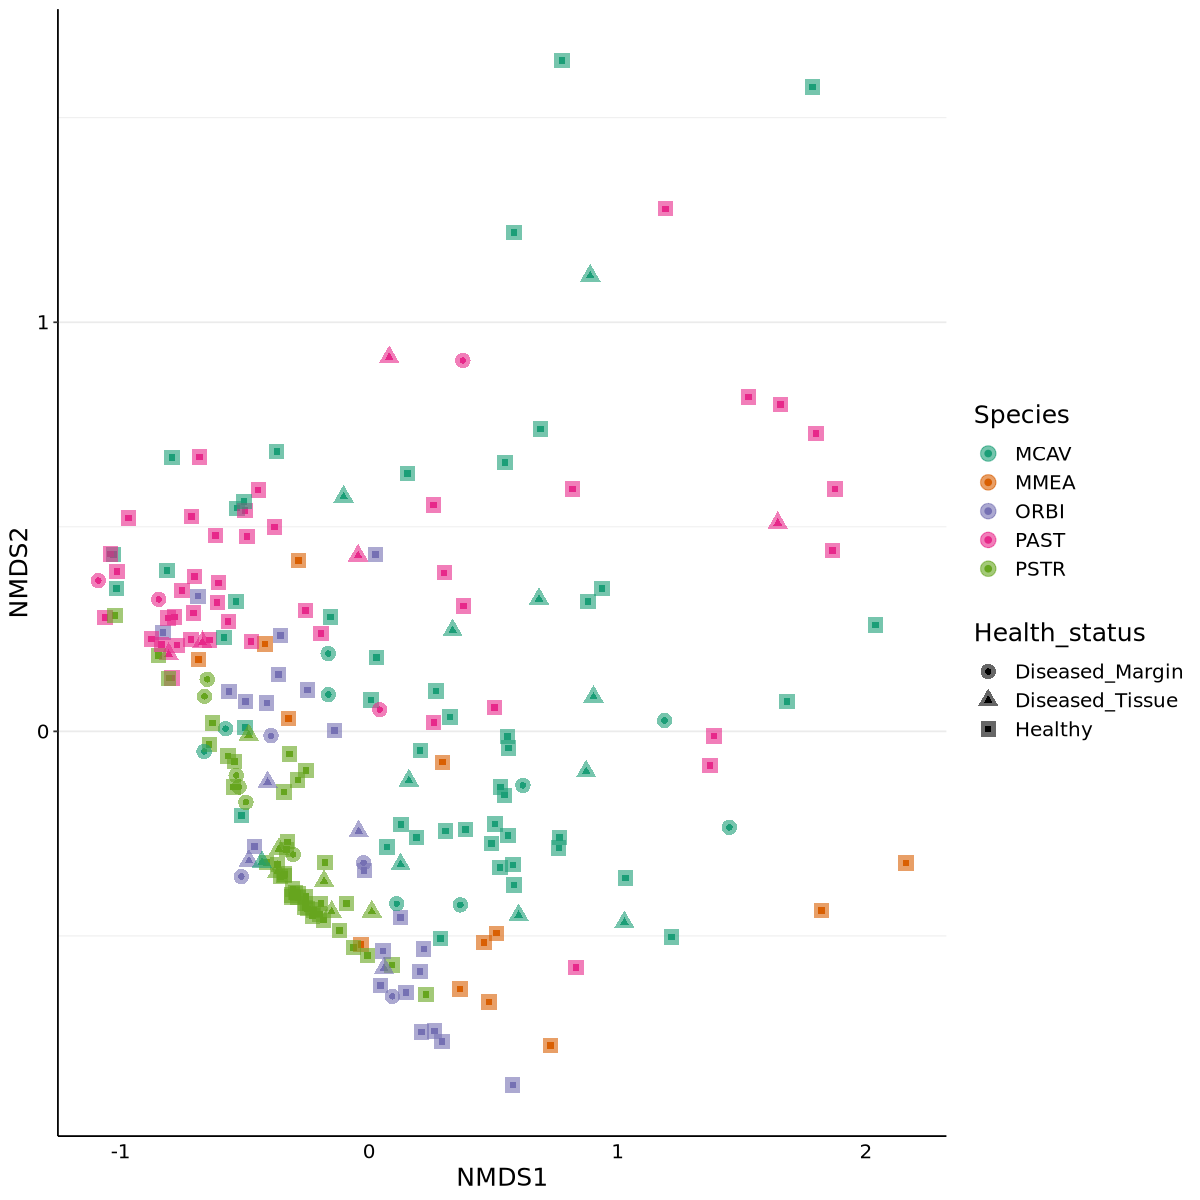

In [185]:
# visualize ordination plot
sctld_all_plot <- plot_ordination(sctld_all2, sctld_all2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
# facet_wrap(
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_all_plot

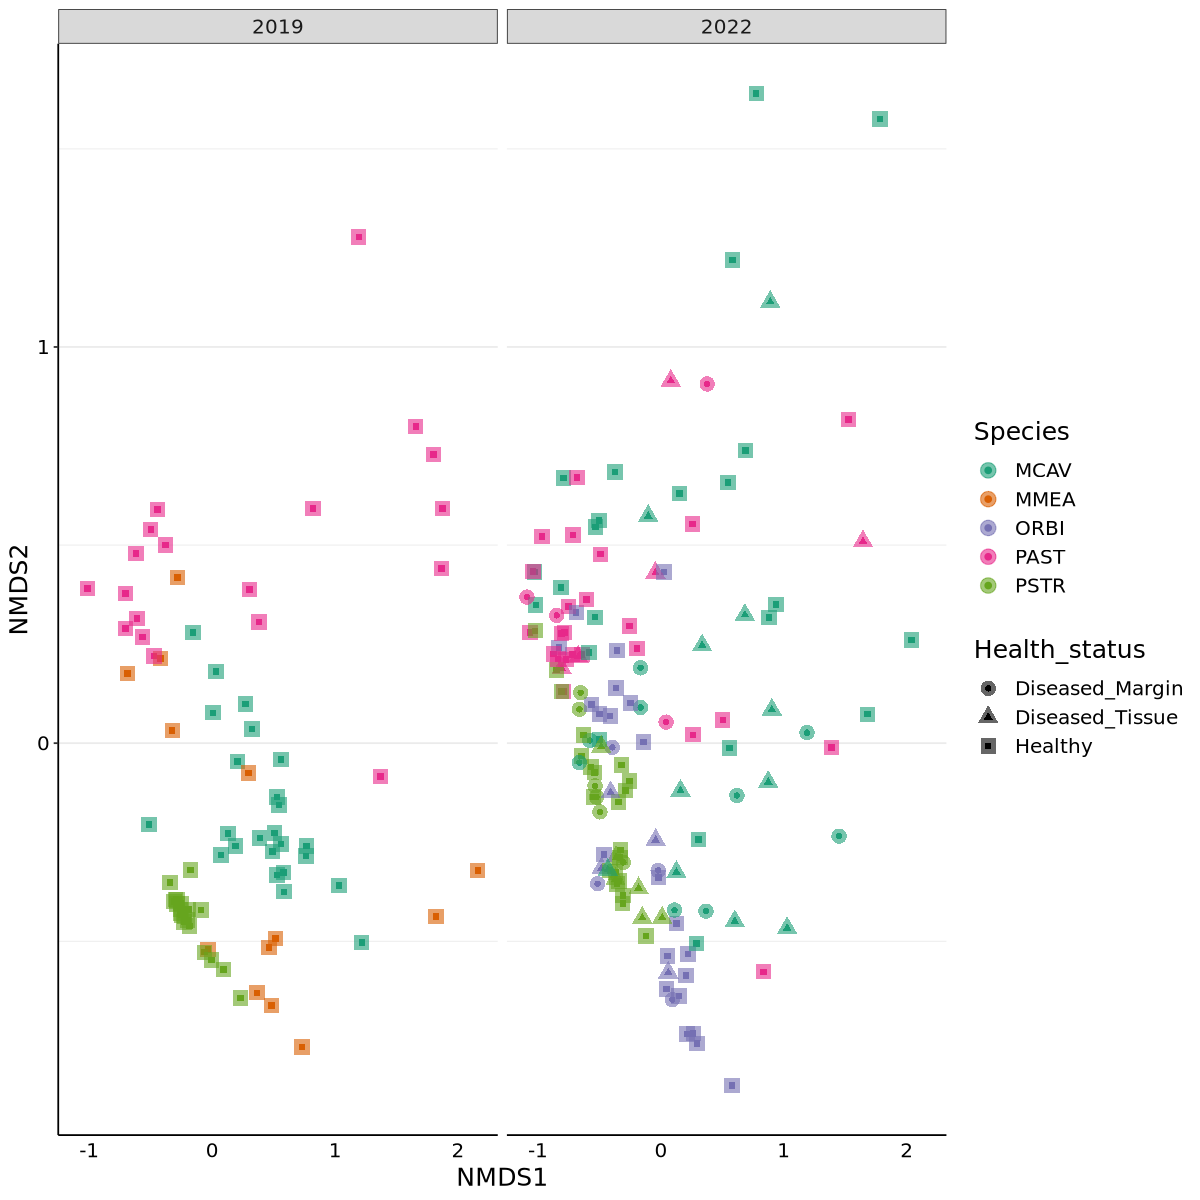

In [194]:
# facet by year
sctld_all_plot <- plot_ordination(sctld_all2, sctld_all2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_all_plot

In [ ]:
# outliers really causing issues - see previous commits to view 
# leaving filtered out for now??

In [223]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_all2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1074398 
Run 1 stress 0.1176493 
Run 2 stress 0.1201989 
Run 3 stress 0.1208505 
Run 4 stress 0.1064491 
... New best solution
... Procrustes: rmse 0.007198554  max resid 0.05781302 
Run 5 stress 0.1064491 
... New best solution
... Procrustes: rmse 4.567412e-05  max resid 0.0002661564 
... Similar to previous best
Run 6 stress 0.1191377 
Run 7 stress 0.1201899 
Run 8 stress 0.1201933 
Run 9 stress 0.1180725 
Run 10 stress 0.1140513 
Run 11 stress 0.1074398 
Run 12 stress 0.1074398 
Run 13 stress 0.1180725 
Run 14 stress 0.1064491 
... New best solution
... Procrustes: rmse 3.70244e-05  max resid 0.0001970449 
... Similar to previous best
Run 15 stress 0.1136383 
Run 16 stress 0.1180725 
Run 17 stress 0.1135785 
Run 18 stress 0.1074398 
Run 19 stress 0.1208821 
Run 20 stress 0.1064571 
... Procrustes: rmse 0.0008888622  max resid 0.006852892 
... Similar to previous best
*** Best solution repeated 2 times


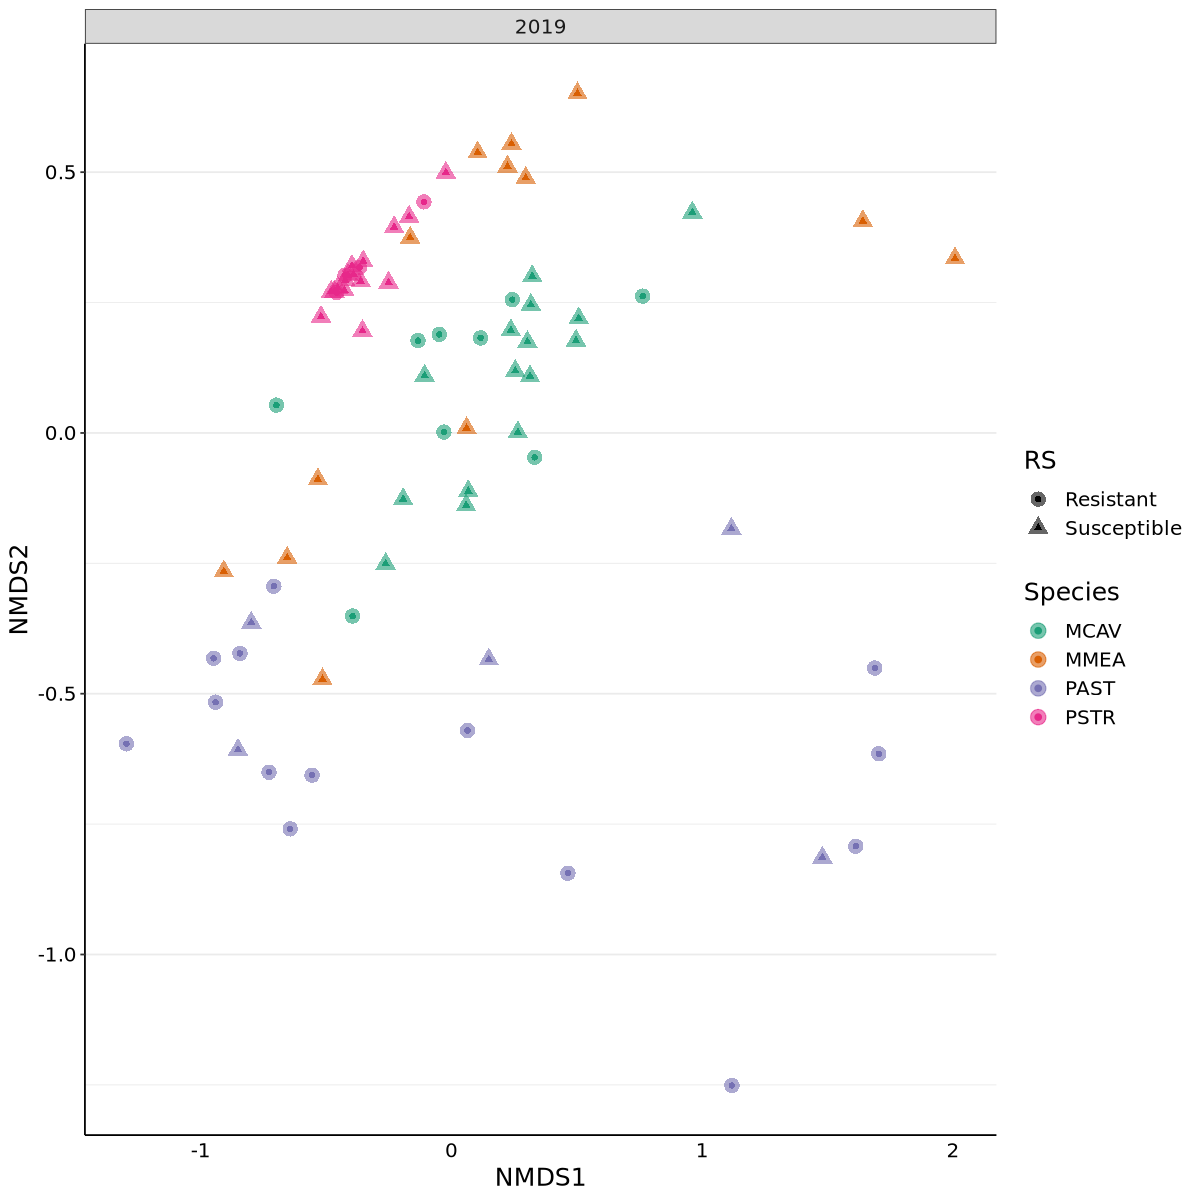

In [224]:
plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

In [78]:
# ggsave(filename = "taxonomy_species_nmds.png", plot = sctld_all_plot, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


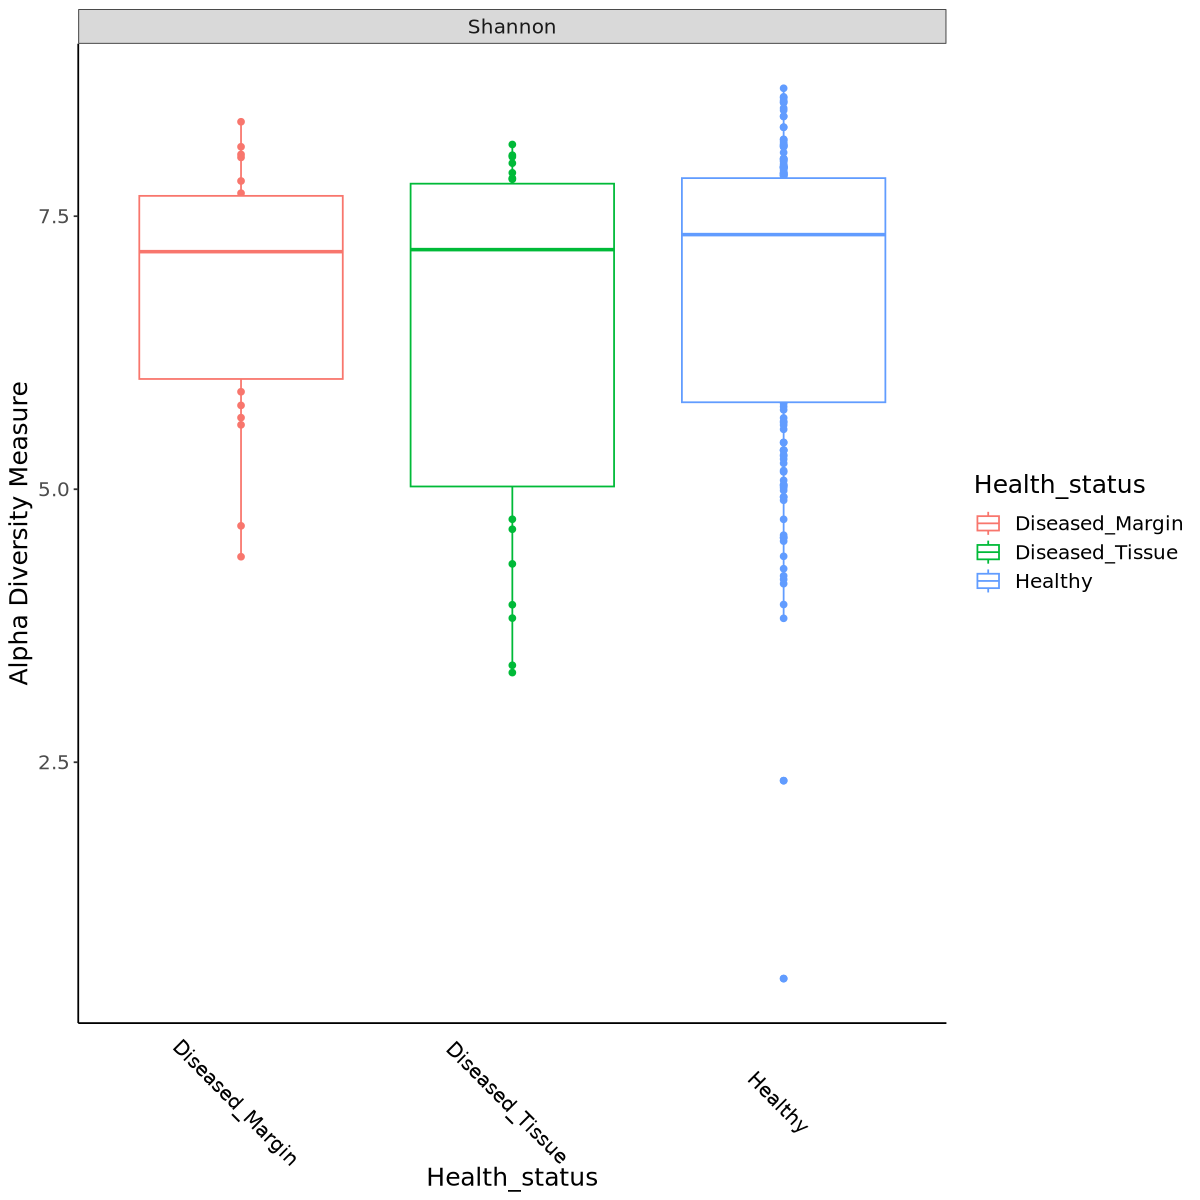

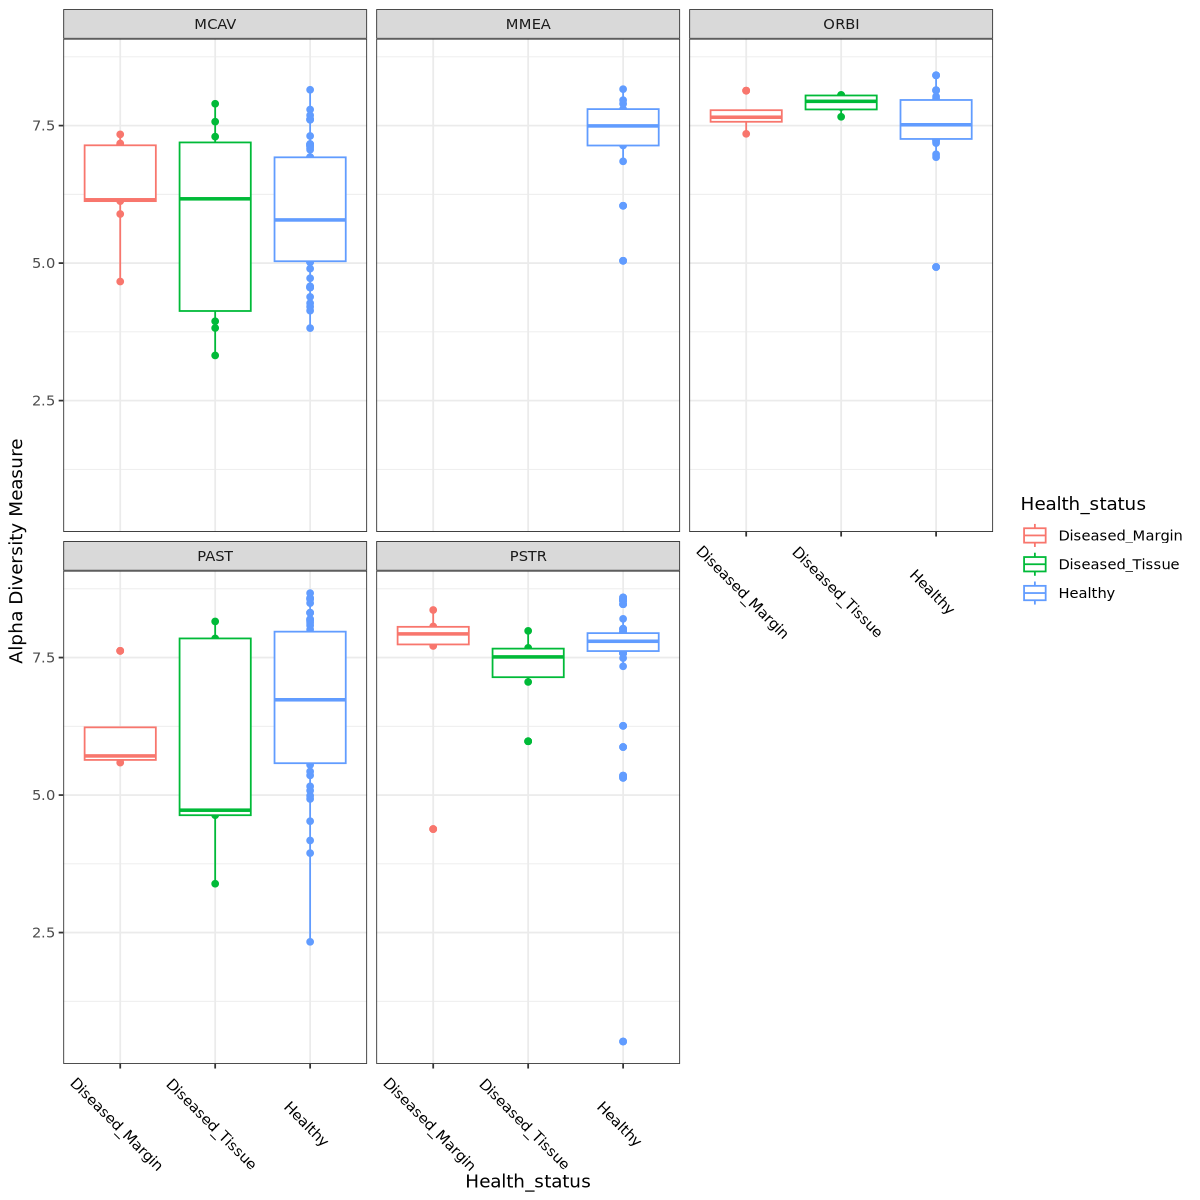

In [212]:
rich_status <- plot_richness(sctld_all, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
# facet_wrap(~Species)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
    text = element_text(size = 15))
rich_status

plot_richness(sctld_all, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

In [81]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


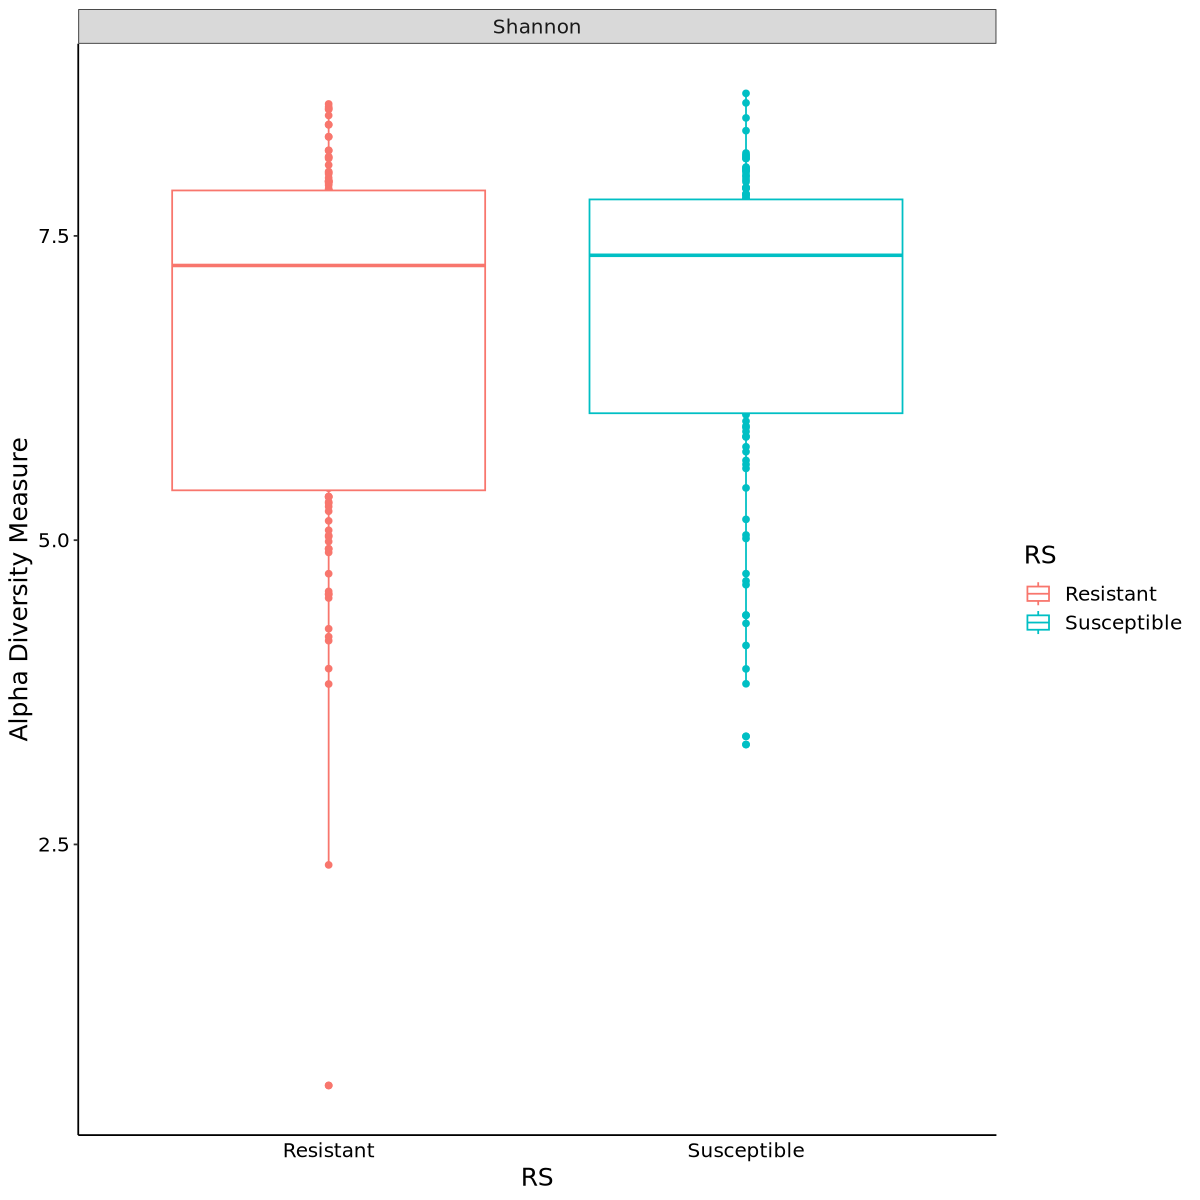

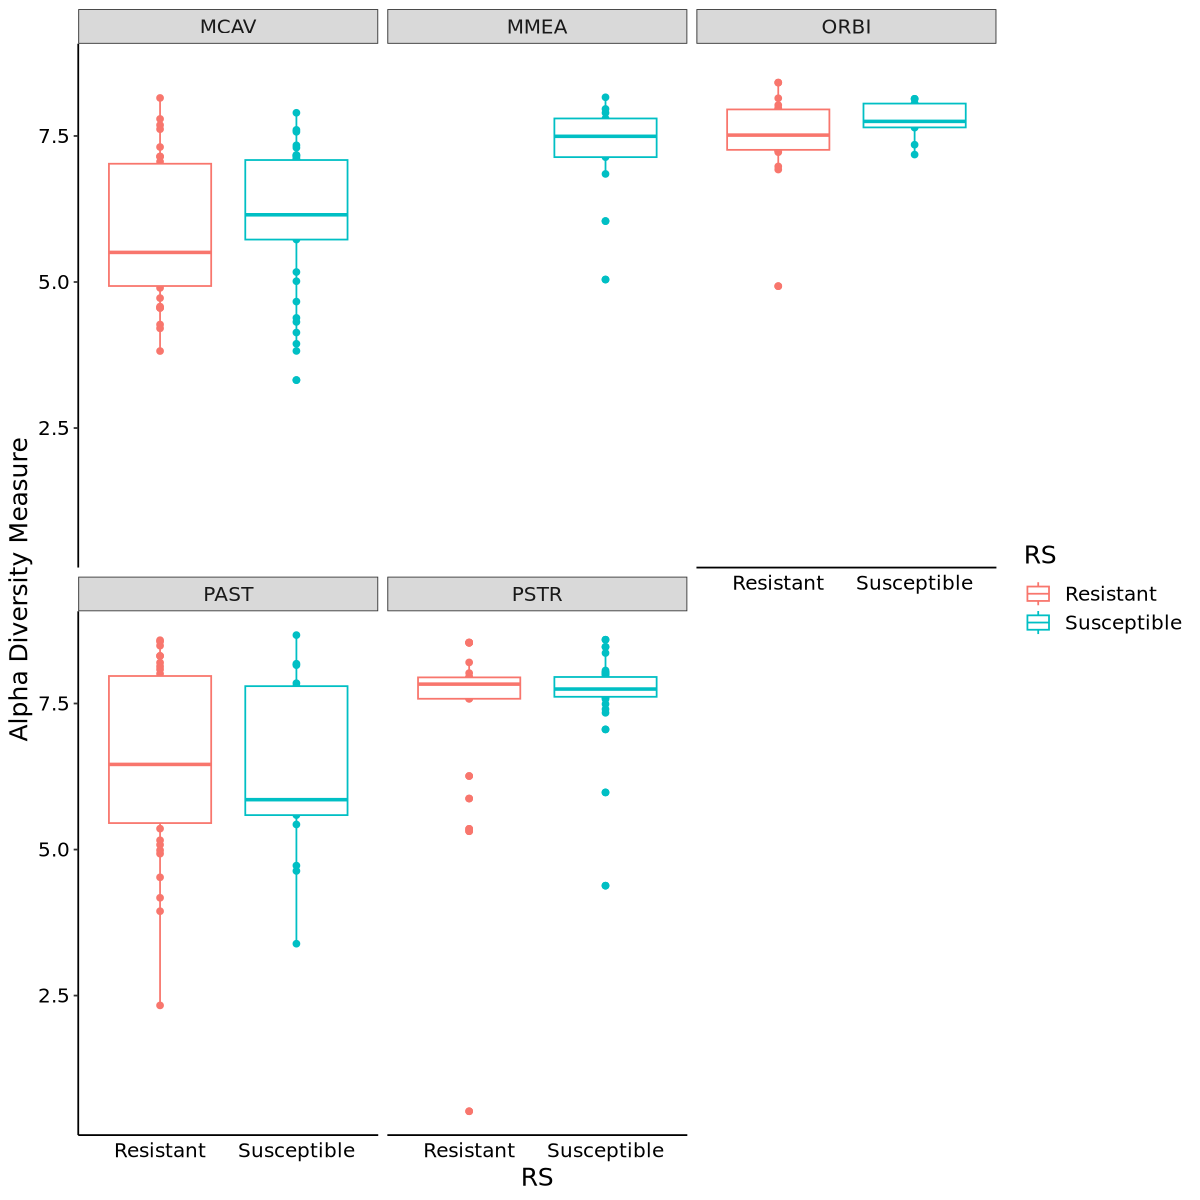

In [216]:
rich_status1 <- plot_richness(sctld_all, x="RS", color="RS", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_wrap(~Species)

In [84]:
# ggsave(filename = "shannon_richness_sctld_status.png", plot = rich_status1, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [85]:
options(repr.plot.width=15, repr.plot.height=10)

In [ ]:
# rich_species <- plot_richness(sctld_all, x="Species", color="SCTLD_status", measures=c("Shannon")) + geom_point() +
# theme_bw()+
#  theme(legend.position = "right",
#     panel.border = element_blank(),
#     panel.grid.major.x = element_blank(),
#     panel.grid.minor.x = element_blank(),
#     axis.ticks.x = element_blank(),
#     axis.line = element_line(color = "black"),
#     axis.text = element_text(color = "black"),
#     text = element_text(size = 15))
# rich_species

In [217]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_all2, method = "bray")

In [218]:
metadata2 <- as(phyloseq::sample_data(sctld_all2), "data.frame")

In [220]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.041 0.02220  7.0723  0.001 ***
Species           4   13.229 0.28210 22.4722  0.001 ***
year              1    1.119 0.02386  7.6018  0.001 ***
RS:Species        3    0.523 0.01116  1.1849  0.276    
RS:year           1    0.126 0.00268  0.8529  0.486    
Species:year      2    1.118 0.02385  3.7992  0.001 ***
RS:Species:year   2    0.305 0.00651  1.0374  0.372    
Residual        200   29.434 0.62766                   
Total           214   46.896 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#### DESeq2 on sctld_all just to see

In [40]:
#run DESeq2
ds_all = phyloseq_to_deseq2(sctld_all, ~ Sample_type)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE, contrast=c("Sample_type", "H", "DM"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(sctld_all)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 4728 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): Sample_type H vs DM 
Wald test p-value: Sample type H vs DM 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue      padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric> <numeric>
2057741  13420.97       4.427914  1.156079  3.830113 0.000128084 0.0010367
5722      5178.90       0.589072  0.867900  0.678733 0.497307260 0.8344786
562      10037.11      -0.646347  0.808314 -0.799623 0.423929265 0.7881339
588596    8318.00      -0.136506  0.634502 -0.215138 0.829659641 0.9582205
573       6456.22      -0.653278  0.823932 -0.792878 0.427848818 0.7903811
...           ...            ...       ...       ...         ...       ...
2845680   0.32806       -3.60694    3.9129 -0.921807    0.356629  0.736377
1923622   0.32806       -3.60694    3.9129 -0.921807    0.356629  0.736377
3048237   0.32806       -3.60694    3.9129 -0.921807    0.356629  0.736377
3060633   0.32806       -3.60694    3.9129 -0.9218

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2653203,2068.17628,-15.66042,2.225075,-7.038153,1.948044e-12,1.504372e-10,Sphingomonas sp. CL5.1
3003349,1043.82120,-14.79366,2.497568,-5.923226,3.156859e-09,2.642440e-08,Marinobacter sp. LM1
2774873,141.14272,-27.93895,3.865612,-7.227562,4.917423e-13,7.084560e-11,Pseudomonas sp. ADPe
2420300,340.72265,-29.04396,3.865475,-7.513684,5.748644e-14,2.199934e-11,Acinetobacter sp. FDAARGOS_493
2831149,99.01244,-27.67615,3.865662,-7.159486,8.098025e-13,9.355511e-11,Streptomyces sp. V17-9
3369658,399.98012,-13.42918,2.517024,-5.335341,9.536541e-08,7.864275e-07,Marinobacter sp. W-8


In [41]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
head(sorted_sigtab_all)
dim(sorted_sigtab_all)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3158171,372.93152,-29.75472,2.798649,-10.631816,2.119438e-26,2.595464e-22,Marinobacter sp. RI1
658446,118.87199,-28.36928,3.035791,-9.344938,9.194349e-21,5.629700e-17,Paracoccus fistulariae
225422,74.41589,-27.71564,3.001877,-9.232770,2.637227e-20,1.076516e-16,Sulfitobacter indolifex
52603,84.70138,-27.75445,3.026181,-9.171443,4.667286e-20,1.428890e-16,Sagittula stellata
1327635,39.88781,-26.70225,3.003139,-8.891448,6.031759e-19,1.477298e-15,Sphingomonas psychrotolerans
267128,78.45033,-27.56366,3.315490,-8.313602,9.283981e-17,1.894861e-13,Sphingopyxis granuli


[1] 1502    7

In [42]:
#include just the top 25 for now
sorted_sigtab_all_25 <- head(sorted_sigtab_all, 25)
sorted_sigtab_all_25

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3158171,372.93152,-29.75472,2.798649,-10.631816,2.119438e-26,2.595464e-22,Marinobacter sp. RI1
658446,118.87199,-28.36928,3.035791,-9.344938,9.194349e-21,5.629700e-17,Paracoccus fistulariae
225422,74.41589,-27.71564,3.001877,-9.232770,2.637227e-20,1.076516e-16,Sulfitobacter indolifex
52603,84.70138,-27.75445,3.026181,-9.171443,4.667286e-20,1.428890e-16,Sagittula stellata
1327635,39.88781,-26.70225,3.003139,-8.891448,6.031759e-19,1.477298e-15,Sphingomonas psychrotolerans
267128,78.45033,-27.56366,3.315490,-8.313602,9.283981e-17,1.894861e-13,Sphingopyxis granuli
3394605,49.33909,-27.10024,3.270813,-8.285475,1.176389e-16,2.058008e-13,Massilia sp. GER05
2184161,149.42392,-27.78505,3.377826,-8.225720,1.940217e-16,2.969987e-13,Oceaniradius stylonematis
2721173,48.13493,-26.84224,3.292296,-8.153046,3.548695e-16,4.828591e-13,Streptomyces sp. DSM 40868


In [45]:
# subset top 20 taxa that are assoc with DM
DM_all_otu<-sorted_sigtab_all[sorted_sigtab_all$log2FoldChange<0,]
DM_all_otu_20 <- head(DM_all_otu, 20)
DM_all_otu_20

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3158171,372.93152,-29.75472,2.798649,-10.631816,2.119438e-26,2.595464e-22,Marinobacter sp. RI1
658446,118.87199,-28.36928,3.035791,-9.344938,9.194349e-21,5.629700e-17,Paracoccus fistulariae
225422,74.41589,-27.71564,3.001877,-9.232770,2.637227e-20,1.076516e-16,Sulfitobacter indolifex
52603,84.70138,-27.75445,3.026181,-9.171443,4.667286e-20,1.428890e-16,Sagittula stellata
1327635,39.88781,-26.70225,3.003139,-8.891448,6.031759e-19,1.477298e-15,Sphingomonas psychrotolerans
267128,78.45033,-27.56366,3.315490,-8.313602,9.283981e-17,1.894861e-13,Sphingopyxis granuli
3394605,49.33909,-27.10024,3.270813,-8.285475,1.176389e-16,2.058008e-13,Massilia sp. GER05
2184161,149.42392,-27.78505,3.377826,-8.225720,1.940217e-16,2.969987e-13,Oceaniradius stylonematis
2721173,48.13493,-26.84224,3.292296,-8.153046,3.548695e-16,4.828591e-13,Streptomyces sp. DSM 40868


In [43]:
# subset taxa that are assoc with healthy
healthy_all_otu<-sorted_sigtab_all[sorted_sigtab_all$log2FoldChange>0,]
healthy_all_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
34087,157.019466,22.91405,3.292531,6.959402,3.417206e-12,2.051329e-10,Sphingobacterium faecium
202,39.636852,21.06297,3.340761,6.304844,2.884843e-10,2.826223e-09,Campylobacter mucosalis
141,73.278269,22.56775,3.700679,6.098272,1.072213e-09,9.318896e-09,Borrelia parkeri
2843630,126.602407,22.66354,3.750786,6.042346,1.518895e-09,1.296195e-08,Acajnonavirus acj9
2490635,89.400513,23.02216,3.944010,5.837247,5.307045e-09,4.436182e-08,Pseudoalteromonas sp. Xi13
882104,31.759444,20.93848,3.621830,5.781186,7.417570e-09,6.191926e-08,Methanoregula formicica
34061,19.222825,19.64194,3.461850,5.673830,1.396400e-08,1.164079e-07,Moraxella cuniculi
1536774,65.218570,20.95922,3.698503,5.666946,1.453647e-08,1.210977e-07,Paenibacillus sp. FSL H7-0357
2745511,35.952169,21.87225,3.896536,5.613255,1.985561e-08,1.651847e-07,Pseudomonas tensinigenes


In [47]:
#combine top DM and H lfc taxa
top_lfc_otus <- rbind(healthy_all_otu, DM_all_otu_20)

In [48]:
write.csv(top_lfc_otus, file="DR_top_lfc_otus_HvDM.csv")

In [50]:
#added enriched column with designation of H or DM
top_lfc_otus_ready <- read.csv("DR_top_lfc_otus_HvDM.csv")

In [65]:
options(repr.plot.width=15, repr.plot.height=15)

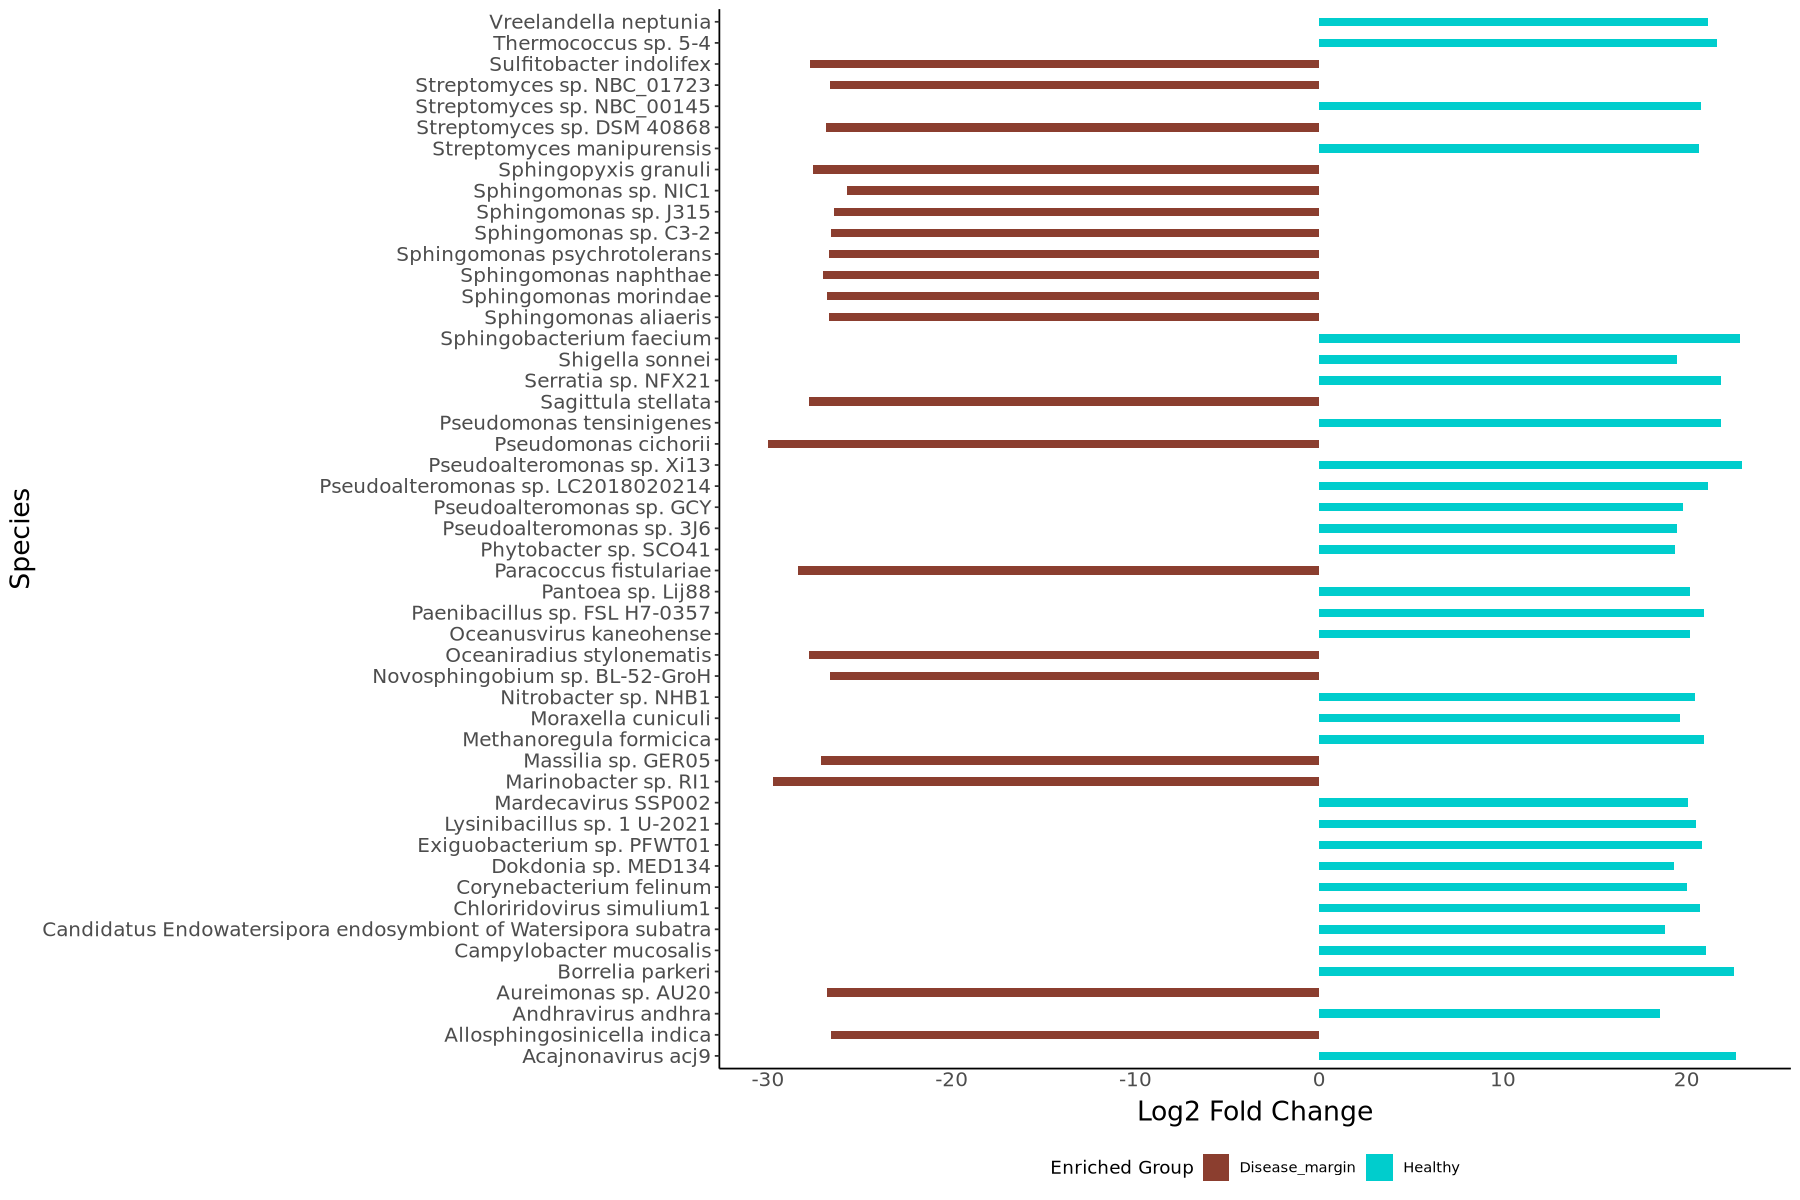

In [93]:
# plot significantly different OTUs top 20
top_lfc_all_plot <- ggplot(top_lfc_otus_ready, aes(x = species, y = log2FoldChange, fill = enriched)) +
  geom_bar(stat = "identity", width = 0.4) +
  coord_flip() + # Rotates the bars horizontally
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 16),   # Adjust y-axis title size and add margin
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
  labs(x = "Species", y = "Log2 Fold Change", fill = "Enriched Group") +
scale_fill_manual(values= c("Healthy"="cyan3", "Disease_margin"="coral4"))

top_lfc_all_plot

In [94]:
ggsave(filename = "DR_top_lfc_all_plot_HvDM_res.png", plot = top_lfc_all_plot, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

In [88]:
#run DESeq2 on DT vs DM
ds_all_d = phyloseq_to_deseq2(sctld_all, ~ Sample_type)
ds_all_d = DESeq(ds_all_d, test="Wald", fitType="parametric")
res = results(ds_all_d, cooksCutoff = FALSE, contrast=c("Sample_type", "DT", "DM"))
alpha = 0.00001
sigtab = res[which(res$padj < alpha), ]
sigtab_d = cbind(as(sigtab, "data.frame"), as(tax_table(sctld_all)[rownames(sigtab), ], "matrix"))
res
head(sigtab_d)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 4728 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): Sample_type DT vs DM 
Wald test p-value: Sample type DT vs DM 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat    pvalue      padj
        <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
2057741  13420.97     -1.2731226  1.543234 -0.8249708  0.409388         1
5722      5178.90     -0.0949425  1.158314 -0.0819661  0.934674         1
562      10037.11     -0.7735400  1.078807 -0.7170328  0.473354         1
588596    8318.00     -0.2047533  0.846817 -0.2417917  0.808942         1
573       6456.22     -0.7289242  1.099651 -0.6628688  0.507415         1
...           ...            ...       ...        ...       ...       ...
2845680   0.32806       -3.28613   5.25677  -0.625124   0.53189         1
1923622   0.32806       -3.28613   5.25677  -0.625124   0.53189         1
3048237   0.32806       -3.28613   5.25677  -0.625124   0.53189         1
3060633   0.32806       -3.28613   5.25677  -0.625124   0.5

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2093780,179.57431,-24.81915,4.141137,-5.993319,2.056010e-09,2.347421e-06,Podospora pseudopauciseta
1014,71.50343,-22.20394,3.803410,-5.837903,5.286207e-09,4.623921e-06,Weeksella virosa
374106,100.98406,-21.28612,3.542815,-6.008252,1.875338e-09,2.347421e-06,Campylobacter cuniculorum
435912,136.16482,-25.87055,4.545748,-5.691152,1.261852e-08,7.358398e-06,Vibrio porteresiae
1642646,157.36575,-22.71836,3.951493,-5.749312,8.960754e-09,6.454905e-06,Petrimonas mucosa
1844006,133.87570,-25.07277,4.164123,-6.021140,1.731930e-09,2.347421e-06,Phaeobacter porticola


In [90]:
# sort by most significant 
sorted_sigtab_d <- sigtab_d %>%
  arrange(padj)
head(sigtab_d)
dim(sigtab_d)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2093780,179.57431,-24.81915,4.141137,-5.993319,2.056010e-09,2.347421e-06,Podospora pseudopauciseta
1014,71.50343,-22.20394,3.803410,-5.837903,5.286207e-09,4.623921e-06,Weeksella virosa
374106,100.98406,-21.28612,3.542815,-6.008252,1.875338e-09,2.347421e-06,Campylobacter cuniculorum
435912,136.16482,-25.87055,4.545748,-5.691152,1.261852e-08,7.358398e-06,Vibrio porteresiae
1642646,157.36575,-22.71836,3.951493,-5.749312,8.960754e-09,6.454905e-06,Petrimonas mucosa
1844006,133.87570,-25.07277,4.164123,-6.021140,1.731930e-09,2.347421e-06,Phaeobacter porticola


[1] 22  7

In [91]:
write.csv(sigtab_d, file="DR_top_lfc_otus_DTvDM.csv")

In [95]:
#added enriched column with designation of DT or DM
top_lfc_otus_d <- read.csv("DR_top_lfc_otus_DTvDM.csv")

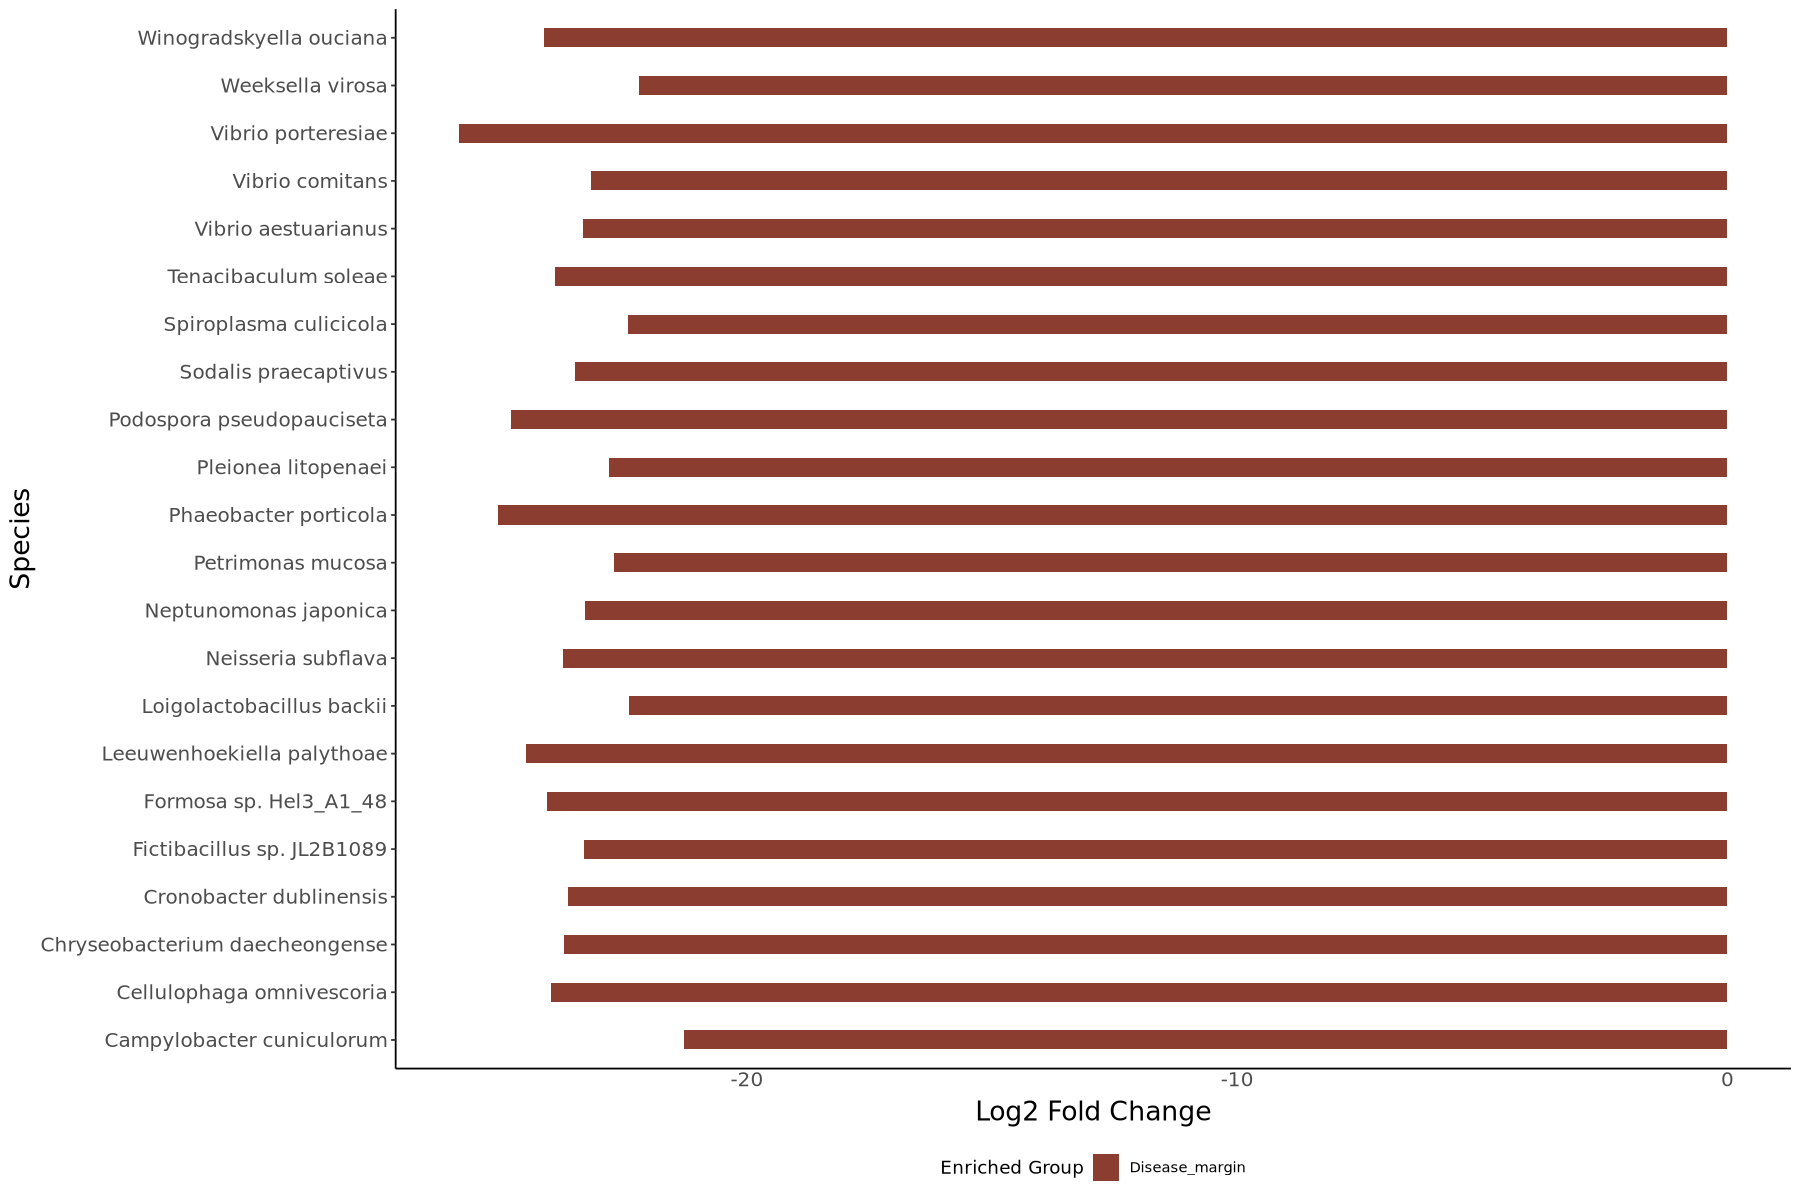

In [96]:
# plot significantly different OTUs top 20
top_lfc_all_d_plot <- ggplot(top_lfc_otus_d, aes(x = species, y = log2FoldChange, fill = enriched)) +
  geom_bar(stat = "identity", width = 0.4) +
  coord_flip() + # Rotates the bars horizontally
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 16),   # Adjust y-axis title size and add margin
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
  labs(x = "Species", y = "Log2 Fold Change", fill = "Enriched Group") +
scale_fill_manual(values= c("Diseased_tissue"="coral1", "Disease_margin"="coral4"))

top_lfc_all_d_plot

In [97]:
ggsave(filename = "DR_top_lfc_all_plot_DTvDM_res.png", plot = top_lfc_all_d_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### let's focus on just MCAV for now (old analysis)

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute



In [30]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species/mcav")

In [31]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('otu_table_normtable_mcav.csv',header=TRUE)
head(otu_mcav)

,X,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [32]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"
head(otu_mcav)
dim(otu_mcav)

,otu,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


[1] 13490     8

In [33]:
#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)
head(otu_table_mcav)

,otu,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [34]:
# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [35]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [36]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [37]:
#read in metadata
metadata_mcav=read.csv('DR_metadata_mcav.csv', header=TRUE)
head(metadata_mcav)
dim(metadata_mcav)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


[1] 7 6

In [38]:
# index the SampleIDs
row.names(metadata_mcav) <- metadata_mcav$SampleID
metadata_mcav$SampleID <- NULL
head(metadata_mcav)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [39]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [40]:
# Create phyloseq object
DR_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
DR_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13490 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 13490 taxa by 1 taxonomic ranks ]

In [41]:
DR_mcav.ord <- ordinate(DR_mcav, "NMDS", "bray")

Square root transformation


Warning message in decostand(x, "max", 2, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”
Warning message in decostand(x, "total", 1, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”


Wisconsin double standardization
Run 0 stress 0.01215683 
Run 1 stress 0.008575588 
... New best solution
... Procrustes: rmse 0.1119286  max resid 0.2648545 
Run 2 stress 0.02349921 
Run 3 stress 0.157905 
Run 4 stress 0.01215683 
Run 5 stress 0.01235787 
Run 6 stress 0.01235789 
Run 7 stress 0.2124849 
Run 8 stress 0.01235792 
Run 9 stress 0.01215687 
Run 10 stress 0.008575594 
... Procrustes: rmse 0.000100494  max resid 0.0001691103 
... Similar to previous best
Run 11 stress 0.01215684 
Run 12 stress 0.01235792 
Run 13 stress 0.008575628 
... Procrustes: rmse 0.0001241158  max resid 0.0002088564 
... Similar to previous best
Run 14 stress 0.2124849 
Run 15 stress 0.02349921 
Run 16 stress 0.01215687 
Run 17 stress 0.01215687 
Run 18 stress 0.01235788 
Run 19 stress 0.01235795 
Run 20 stress 0.01235791 
*** Best solution repeated 2 times


Warning message in metaMDS(veganifyOTU(physeq), distance, ...):
“WA scores were not calculated due to missing values”


In [42]:
options(repr.plot.width=20, repr.plot.height=15)

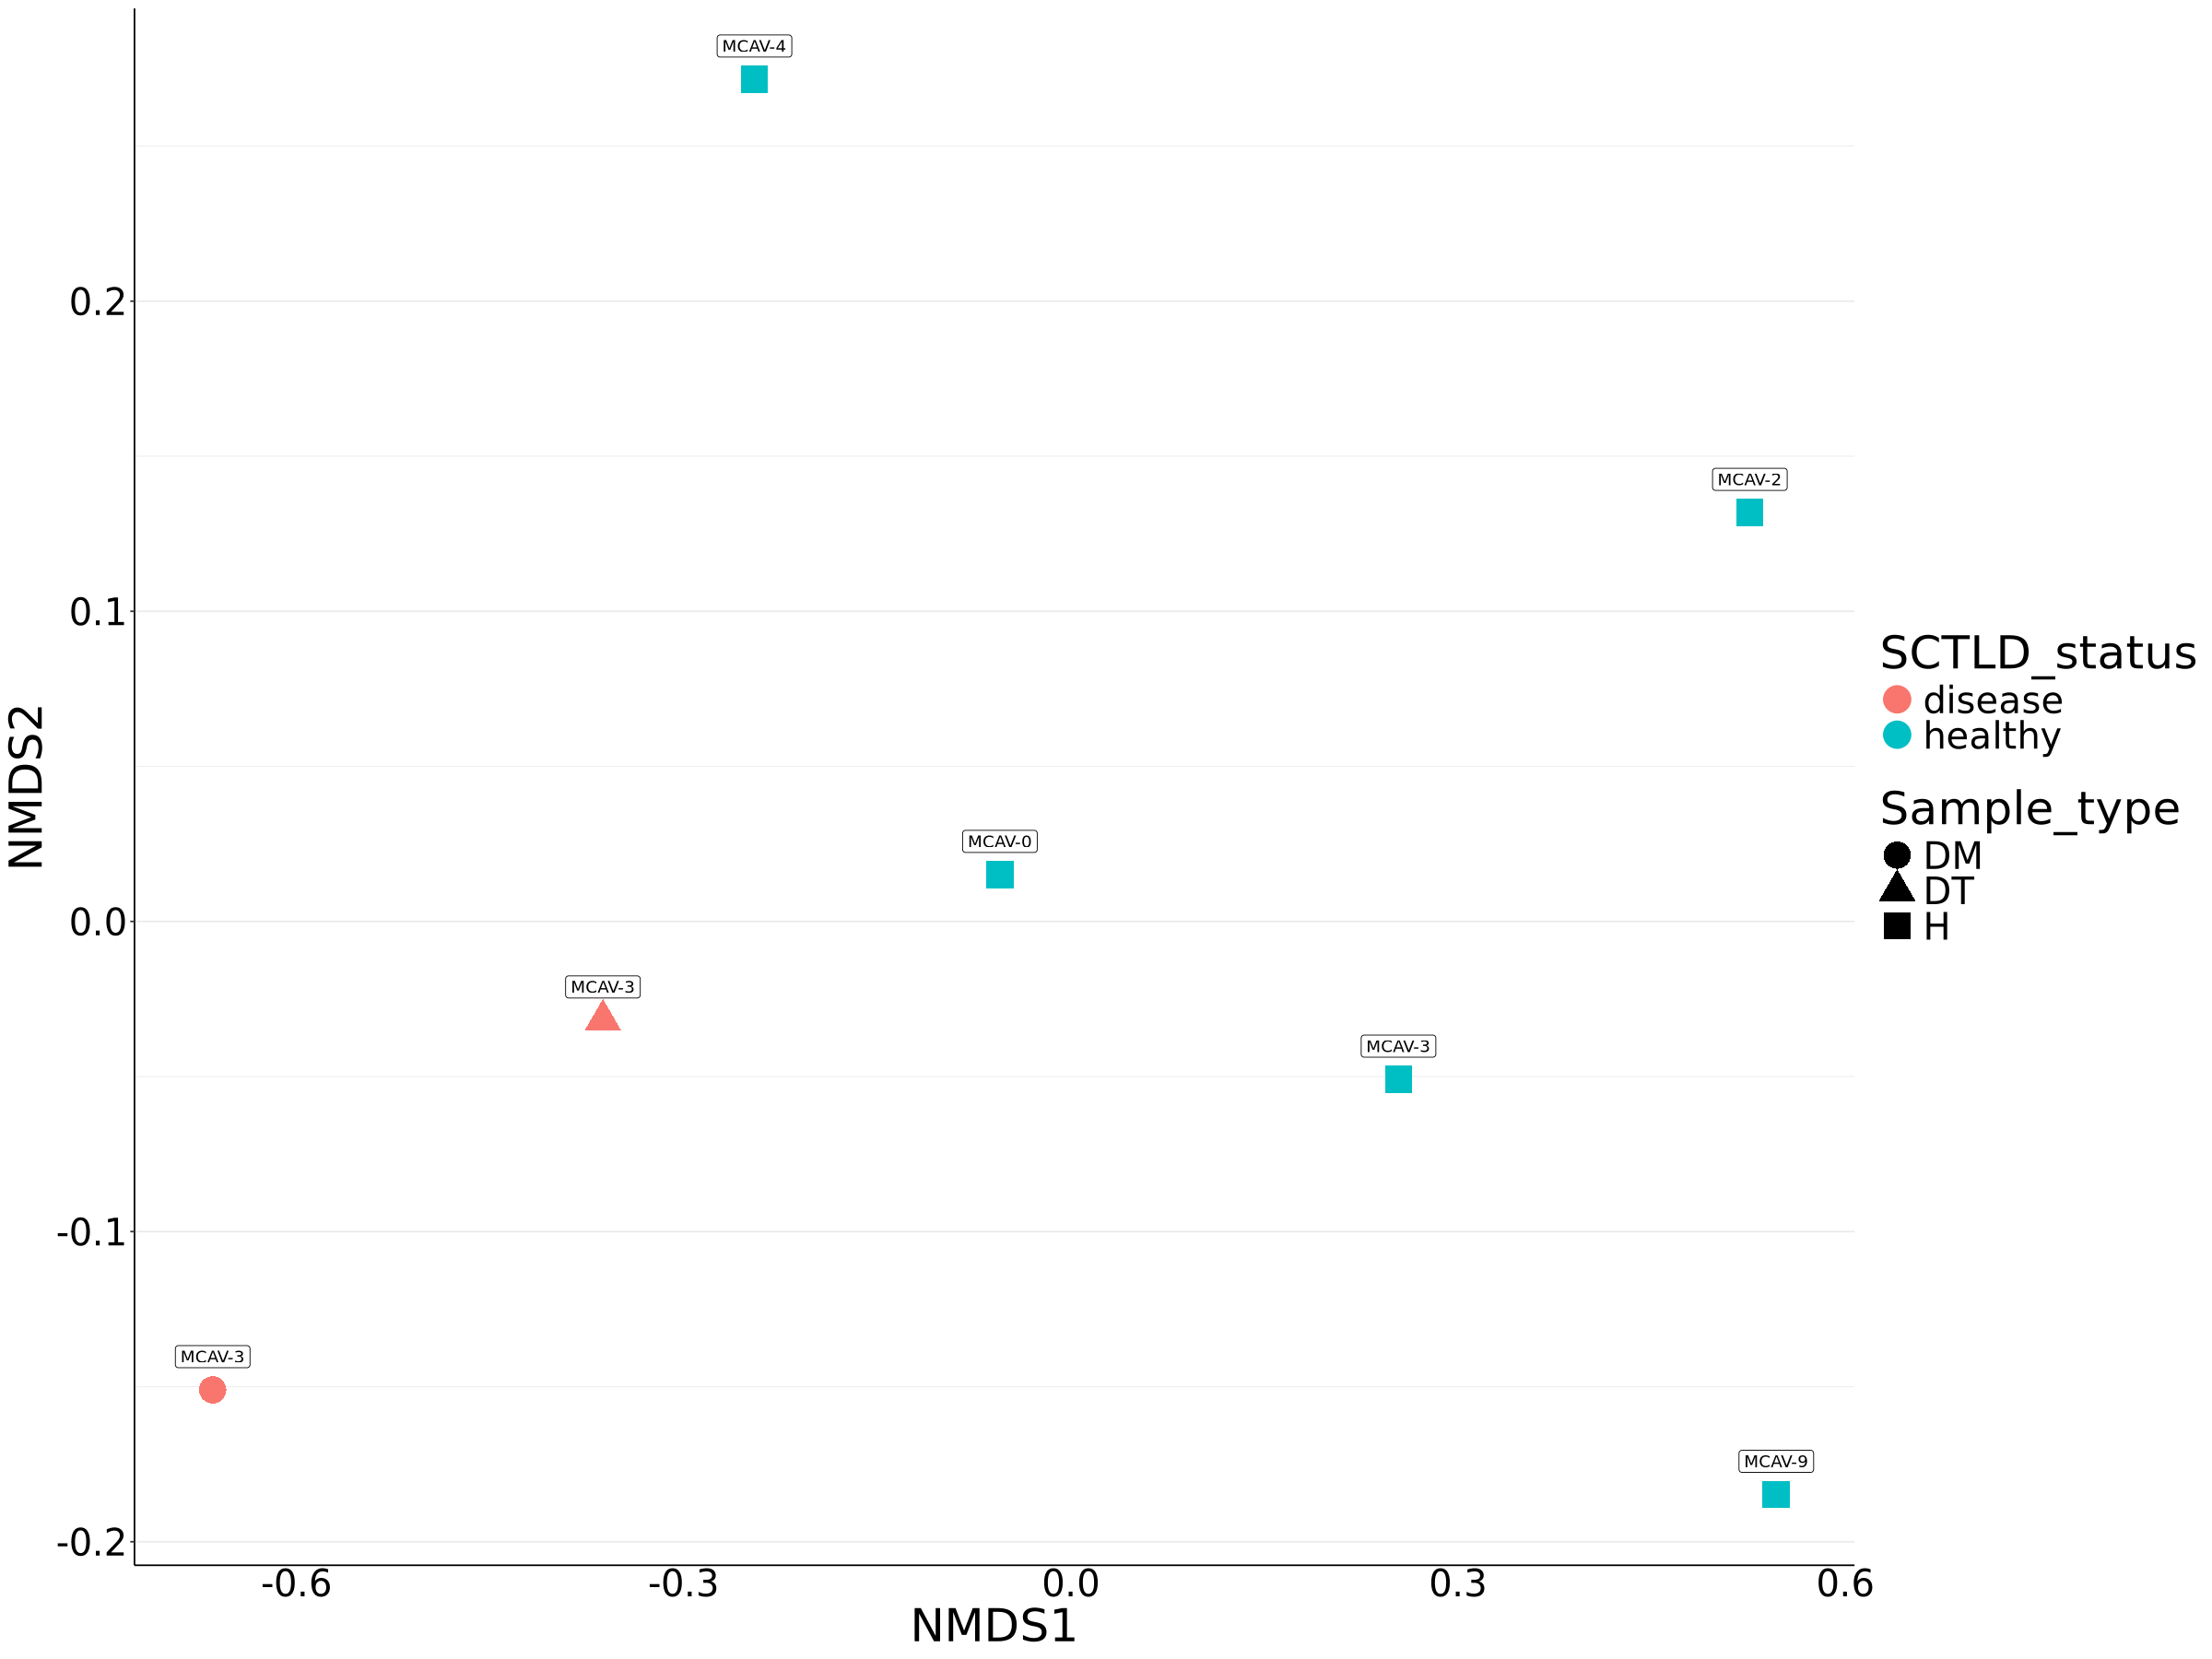

In [78]:
# visualize ordination plot
plot_ordination(DR_mcav, DR_mcav.ord, type="Samples", color="SCTLD_status", shape="Sample_type")+
geom_point(size=8)+
geom_label(aes(label = SAMP_M$Tag_num), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position="right", panel.border = element_blank(),
          panel.grid.major.x = element_blank(),
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(color="black"),
          text = element_text(size=30))

#### DESeq2 on MCAV

In [51]:
#run DESeq2 on mcav
ds_mcav = phyloseq_to_deseq2(DR_mcav, ~ SCTLD_status)
ds_mcav = DESeq(ds_mcav, test="Wald", fitType="parametric")
res = results(ds_mcav, cooksCutoff = FALSE)
alpha = 0.0001
sigtab = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab, "data.frame"), as(tax_table(DR_mcav)[rownames(sigtab), ], "matrix"))
res
head(sigtab_mcav)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): SCTLD status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 13490 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat    pvalue      padj
        <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
2066072  38001.36     -0.3678209  0.338236 -1.0874676  0.276830  0.715196
588596   20796.26      0.2245214  0.228493  0.9826201  0.325794  0.820176
562       7407.83     -0.0208798  0.287964 -0.0725083  0.942197  0.999989
5722      6066.81     -0.0208775  0.264777 -0.0788492  0.937153  0.999989
1280      5623.10     -0.0507102  0.201293 -0.2519224  0.801101  0.999989
...           ...            ...       ...        ...       ...       ...
2774776         0             NA        NA         NA        NA        NA
3378073         0             NA        NA         NA        NA        NA
2913501         0             NA        NA         NA        NA        NA
1967296         0             NA     

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.1468,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
654,812.1445,1.971204,0.3709804,5.313498,1.075408e-07,9.281703e-06,Aeromonas veronii
2034170,1011.5967,-28.465023,3.9245113,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve
584,421.4557,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2704462,516.0504,-13.364421,2.7121245,-4.927658,8.322127e-07,2.887537e-05,Paenibacillus lycopersici
28183,486.4441,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai


In [59]:
# sort by most significant 
sorted_sigtab <- sigtab_mcav %>%
  arrange(padj)
sorted_sigtab

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


In [60]:
#include just the top 20 for now
sorted_sigtab20 <- head(sorted_sigtab, 20)
sorted_sigtab20

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


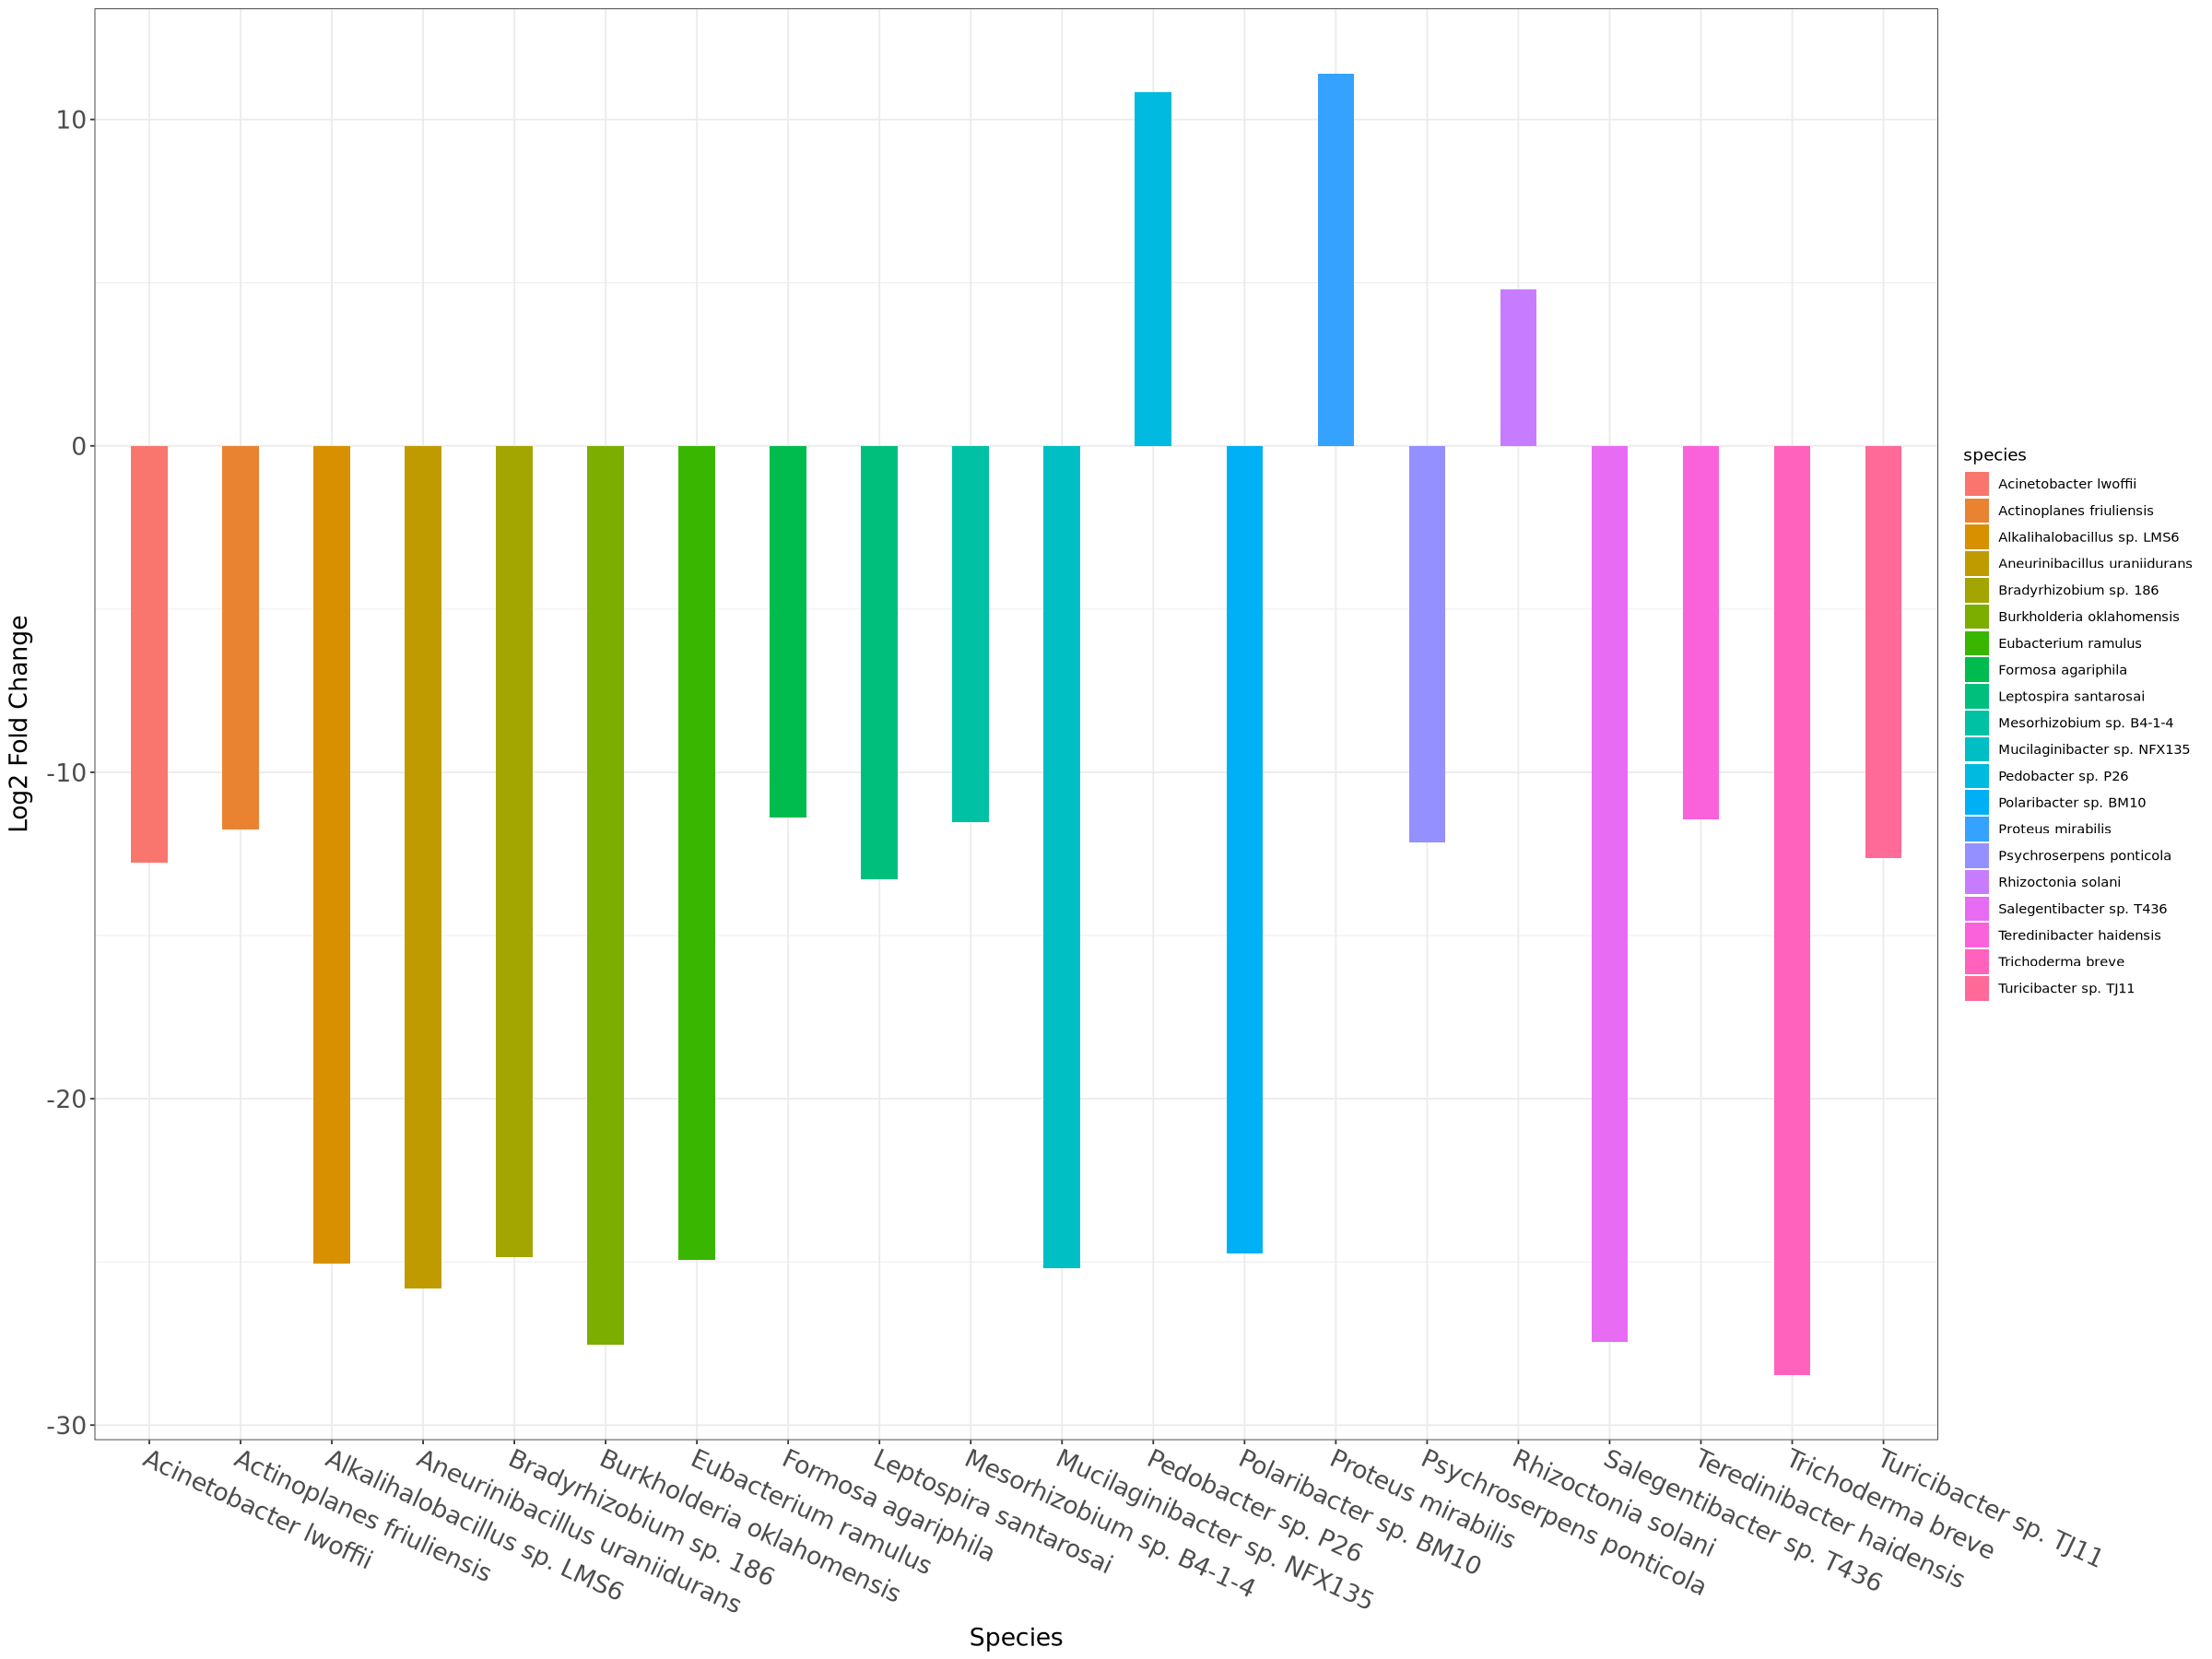

In [65]:
# plot significantly different OTUs top 20
ds_mcav <- ggplot(sorted_sigtab20, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav

In [66]:
#include just the top 30 for now
sorted_sigtab30 <- head(sorted_sigtab, 30)
sorted_sigtab30

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


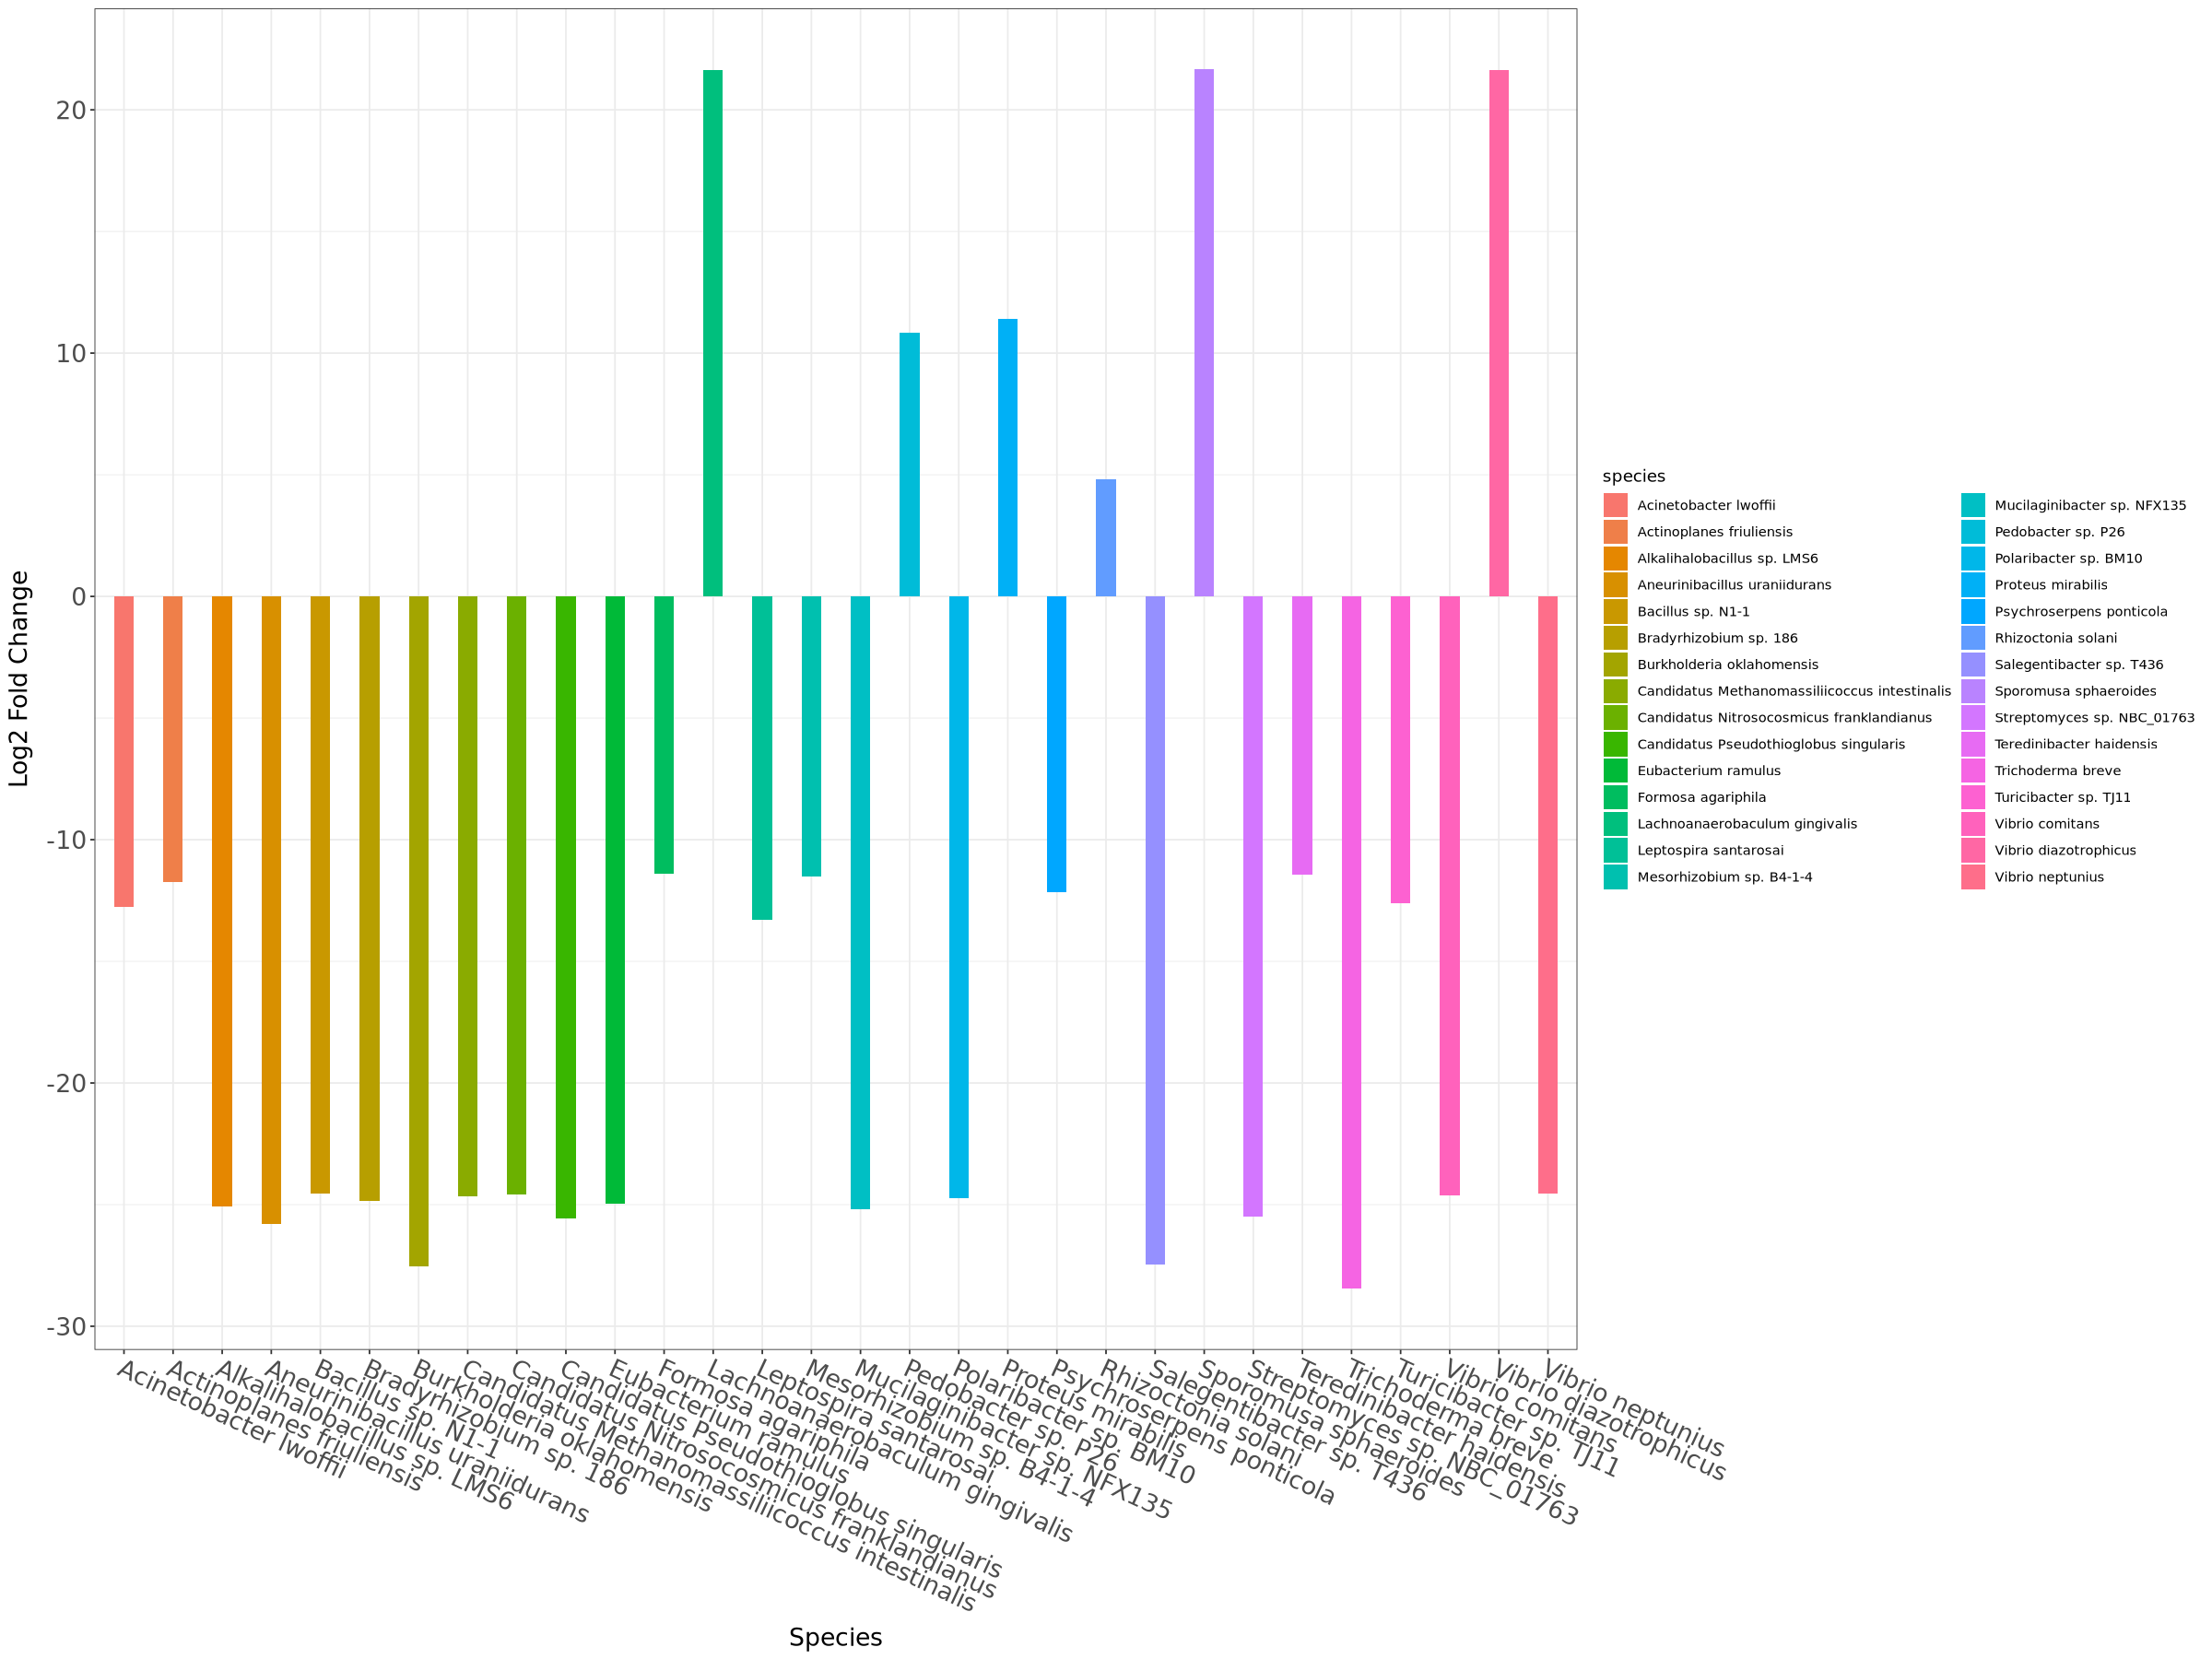

In [67]:
# plot significantly different OTUs top 30
ds_mcav_30 <- ggplot(sorted_sigtab30, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav_30

In [71]:
# subset taxa that are assoc with healthy
healthy_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange>0,]
healthy_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
3423956,282.19532,10.829433,1.5691897,6.901290,5.153243e-12,2.251645e-09,Pedobacter sp. P26
47679,73.53401,21.661404,3.5825332,6.046393,1.481244e-09,3.698350e-07,Sporomusa sphaeroides
685,72.68488,21.645287,3.6006770,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2490855,71.97654,21.632330,3.6159531,5.982470,2.197791e-09,5.121587e-07,Lachnoanaerobaculum gingivalis
1211326,71.33096,21.615639,3.6245179,5.963728,2.465468e-09,5.560029e-07,Spirosoma aerolatum
3077937,69.40902,21.584884,3.6528147,5.909110,3.439612e-09,7.514477e-07,Rickettsiella endosymbiont of Rhagonycha lignosa
251701,69.13542,21.571363,3.6661287,5.883962,4.005592e-09,8.485786e-07,Pseudomonas syringae group genomosp. 3


In [70]:
# subset taxa that are assoc with disease
disease_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange<0,]
disease_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28183,486.44415,-13.27909,1.008581,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.77866,1.054350,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.62567,1.069247,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.15814,1.205288,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.75475,1.407000,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.20764,3.215646,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
2924034,68.41259,-25.06401,3.376232,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6
2589888,143.80086,-11.52107,1.583213,-7.277017,3.412832e-13,2.385911e-10,Mesorhizobium sp. B4-1-4
2034170,1011.59670,-28.46502,3.924511,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve


In [72]:
endo_search <- sorted_sigtab[grepl("Endozoicomonas", sorted_sigtab$species), ]
endo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2872754,13.69932,19.32814,4.038746,4.785678,1.704108e-06,3.599219e-05,Endozoicomonas sp. 4G


In [73]:
pseudo_search <- sorted_sigtab[grepl("Pseudoalteromonas", sorted_sigtab$species), ]
pseudo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28107,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Pseudoalteromonas espejiana
28109,15.42464,19.49318,4.019456,4.849705,1.236450e-06,2.900678e-05,Pseudoalteromonas nigrifaciens
2907156,13.43929,18.70593,4.046588,4.622642,3.788827e-06,6.572627e-05,Pseudoalteromonas sp. N1230-9


In [75]:
vibrio_search <- sorted_sigtab[grepl("Vibrio", sorted_sigtab$species), ]
vibrio_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
413401,48.70370,-24.62073,3.802484,-6.474908,9.486944e-11,2.763468e-08,Vibrio comitans
170651,45.86107,-24.54374,3.827452,-6.412553,1.431029e-10,3.705306e-08,Vibrio neptunius
685,72.68488,21.64529,3.600677,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2912314,51.46638,21.16644,4.081114,5.186436,2.143569e-07,1.198855e-05,Vibrio sp. JC009
3232307,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Vibrio sp. HB236076
446372,35.43086,20.64311,4.081414,5.057833,4.240482e-07,1.989611e-05,Vibrio celticus
2819096,85.38113,20.35577,4.080851,4.988118,6.097027e-07,2.680774e-05,Vibrio sp. SCSIO 43135
3098914,25.19916,20.17505,4.081804,4.942680,7.705576e-07,2.887537e-05,Vibrio iocasae
664643,22.48011,20.01476,4.081968,4.903212,9.428204e-07,2.887537e-05,Vibrio plantisponsor


### Try running Lefse on this phyloseq object
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [ ]:
#get other libraries loaded


#install this package
install.packages("remotes")
remotes::install_github("yiluheihei/microbiomeMarker")

maybe filter the asv table a bit more for taxa, to keep in mind:
https://david-barnett.github.io/microViz/reference/tax_filter.html